# Proyecto: Dinámica del dólar en periodos de estrés y regímenes de mercado

Este proyecto analiza el comportamiento del tipo de cambio USD/MXN desde una perspectiva macroeconómica y cuantitativa, con énfasis en periodos de crisis global como la pandemia de COVID-19. El objetivo no es establecer relaciones rígidas o permanentes entre variables, sino entender cómo estas cambian dependiendo del entorno económico.

Bajo este enfoque, la investigación se centra en la siguiente pregunta:



In [109]:
import importlib
import macro_analysis.macro_tools as rrm
importlib.reload(rrm)

import Quant_Finance_Project.capm as capm
importlib.reload(capm)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 

# Análisis de Estados Unidos
Para el caso de Estados Unidos, trabajamos con TIPS a 5 y 10 años, además de los U.S. T Notes (DGS) de 5 y 10 años, en adición a nuestros índices de interés, que son el principal *scoop* del proyecto.

*Cabe mencionar que todo el código y nuestras herramientas permiten de forma dinámica agregar cualquier varialbe nueva que sea de nuestro interés.*

#### Diferenciación por horizonte: expectativas de inflación a 5 y 10 años

Con el objetivo de profundizar en el análisis de la dinámica macro-financiera, se extiende el estudio de inflación esperada incorporando dos horizontes temporales: mediano plazo (5 años) y largo plazo (10 años).

Esta distinción es relevante, ya que las expectativas de inflación no son homogéneas a lo largo de la curva temporal. 

Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/EXP_INF_USA5.csv
Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/EXP_INF_USA10.csv


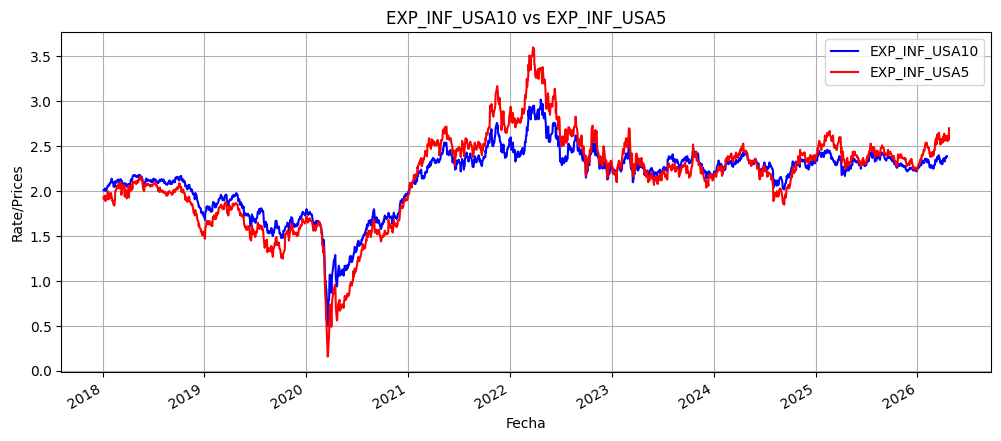

In [8]:
# Obtener la inflación esperada implícita de Estados Unidos a 5 años (derivada de la diferencia entre tasas nominales y reales)
expected_inflation_usa_5 = rrm.synchronise_timseries_df('DGS5', 'TIPS5', 'Cierre', 'Tasa', dif = True)
rrm.cargar_archivo(expected_inflation_usa_5, archivo = 'EXP_INF_USA5')

# Obtener la inflación esperada implícita de Estados Unidos a 10 años (derivada de la diferencia entre tasas nominales y reales)
expected_inflation_usa_10 = rrm.synchronise_timseries_df('DGS10', 'TIPS10', 'Tasa', 'Tasa', dif = True)
rrm.cargar_archivo(expected_inflation_usa_10, archivo = 'EXP_INF_USA10')

rrm.plot_two_timeseries('EXP_INF_USA10', 'EXP_INF_USA5', 'Diferencia', 'Diferencia', titulo = "EXP_INF_USA10 vs EXP_INF_USA5", secondary_y=False)

In [115]:
m = rrm.model('EXP_INF_USA10', 'EXP_INF_USA5', 6)
m.synchronise_timeseries()
m.compute_linear_reg()

print(f"From: {m.timeseries['Fecha'].min()} - To: {m.timeseries['Fecha'].max()}")        
print(f"Corr: {m.correlation}, R2: {m.r_squared}")

From: 2018-01-04 00:00:00 - To: 2026-04-02 00:00:00
Corr: 0.855085, R2: 0.731171


**Mientras que los horizontes de menor plazo tienden a ser más sensibles a condiciones económicas actuales, política monetaria y episodios de estrés, los horizontes de largo plazo suelen reflejar expectativas más estables y ancladas.**

Por ende, realizaremos un estudio considerando distintos horizontes temporales, específicamente a 5 y 10 años, evaluandolos en distintos periodos de tiempo. Esta extensión nos permitirá corroborar si ambos horizontes siguen el mismo comportamiento macro-financiero o no (que por el anterior párrafo no debería) y si presentan diferencias relevantes dependiendo del periodo de tiempo considerado.

Dicho de otra manera, el propósito de este análisis no es únicamente identificar relaciones entre variables, sino entender cómo estas pueden variar en función del horizonte temporal, ya que las expectativas inflacionarias pueden responder de manera diferenciada ante cambios en el entorno económico, política monetaria y episodios de estrés financiero.


## Análisis Exploratorio y Evidencia Empírica Inicial - Enfoque sobre EUA a 5 años

Se inicia con un análisis exploratorio utilizando la totalidad de los datos disponibles (2018–2026). Este enfoque permite establecer un comportamiento base o “normal” del mercado, previo a cualquier evento de estrés.

En una primera etapa, se analizan visualmente distintas combinaciones entre variables macro-financieras, tales como:

* Tasa real vs tasa nominal (TIPS vs DGS)
* Tasa real de Estados Unidos vs inflación
* Tasa real de Estados Unidos vs DXY y USD/MXN
* Inflación esperada vs DXY y USD/MXN

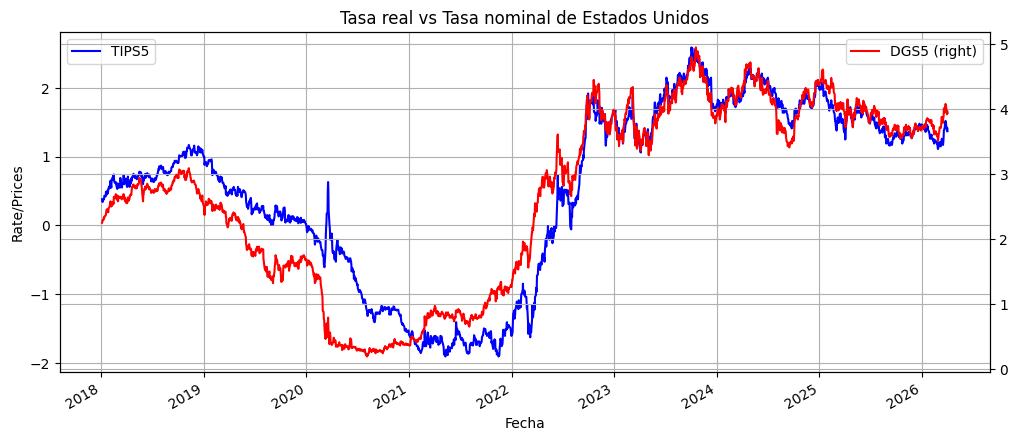

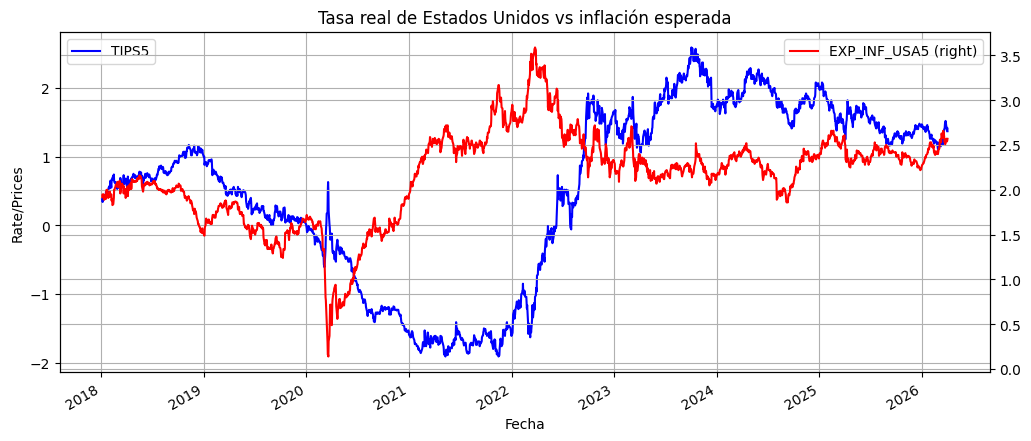

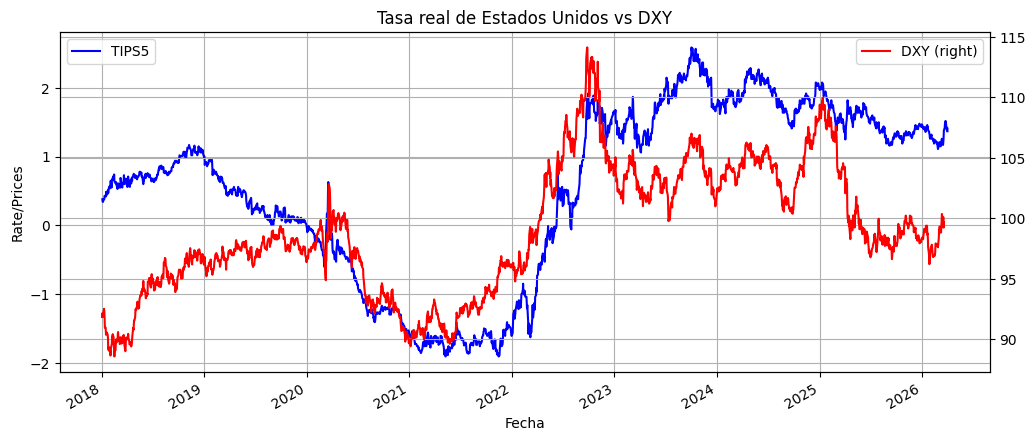

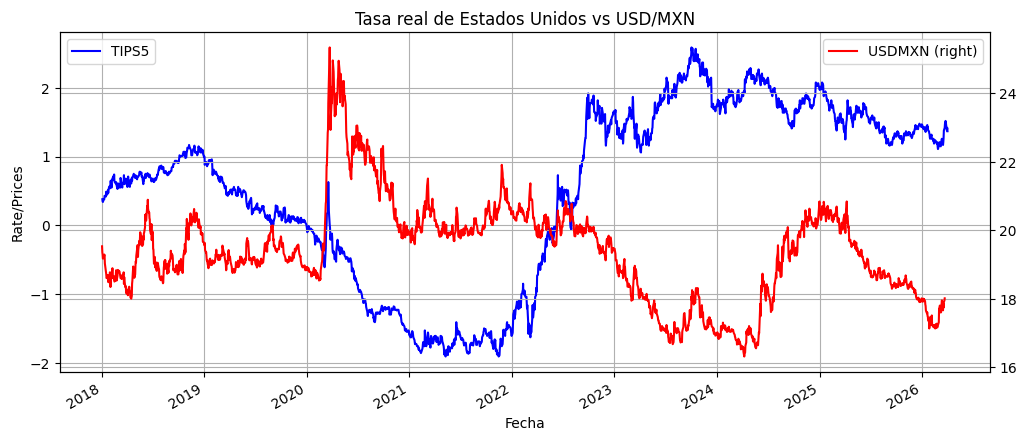

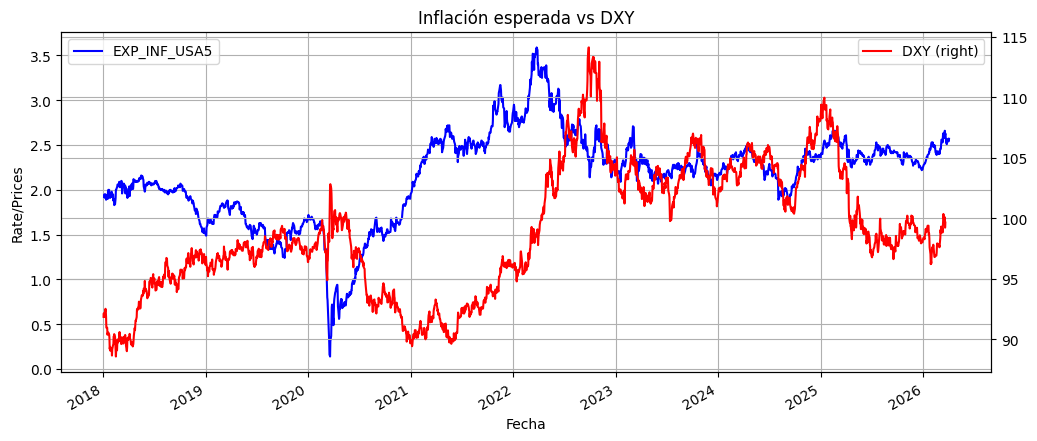

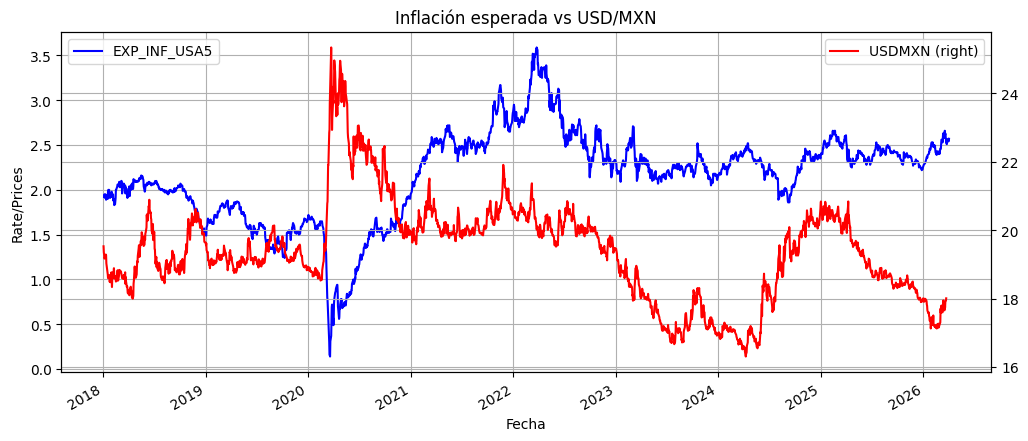

In [116]:
rrm.plot_two_timeseries('TIPS5', 'DGS5', 'Tasa', 'Tasa', titulo = 'Tasa real vs Tasa nominal de Estados Unidos')
rrm.plot_two_timeseries('TIPS5', 'EXP_INF_USA5', 'Tasa', 'Diferencia', titulo = 'Tasa real de Estados Unidos vs inflación esperada') # from_date='2020-01-01', to_date='2020-12-01
rrm.plot_two_timeseries('TIPS5', 'DXY', 'Tasa', 'Cierre', titulo = 'Tasa real de Estados Unidos vs DXY')
rrm.plot_two_timeseries('TIPS5', 'USDMXN', 'Tasa', 'Cierre', titulo = 'Tasa real de Estados Unidos vs USD/MXN')
rrm.plot_two_timeseries('EXP_INF_USA5', 'DXY', 'Diferencia', 'Cierre', titulo = 'Inflación esperada vs DXY')
rrm.plot_two_timeseries('EXP_INF_USA5', 'USDMXN', 'Diferencia', 'Cierre', titulo = 'Inflación esperada vs USD/MXN')

A nivel visual, algunas de estas combinaciones sugieren la posible existencia de relaciones proporcionales e inversas en periodos específicos; sin embargo, dichas asociaciones no resultan concluyentes ni consistentemente visibles a lo largo del tiempo. Esto motiva una evaluación más formal de la relación entre variables.

Para ello, se emplea un análisis con **modelos de regresión lineal simple**, métricas propias del modelo que nos permitirán evaluarlo y gráficos de dispersión para los distintos horizontes temporales.

El tratamiento **automático** de los datos es el siguiente:
* Se estandariza si se trabajan diferentes métricas
* Se usan retornos si se trabaja sobre precios
* Se usa el diferencial en bps si se trabaja sobre tasas o porcentajes

# Marco Analítico: Búsqueda de Poder Explicativo en Ventanas Temporales Deslizantes
El presente análisis emplea un modelo de regresión lineal simple sobre variables estandarizadas, cuyo objetivo central no es la predicción puntual, sino la **cuantificación sistemática del poder explicativo que una variable ejerce sobre otra a lo largo del tiempo**.

La métrica principal es el coeficiente de determinación r^2, complementado por un Score ponderado que ajusta dicho r^2 por el número de observaciones disponibles en cada ventana, penalizando así las relaciones espurias derivadas de muestras reducidas.

La arquitectura de búsqueda opera mediante ventanas temporales deslizantes no superpuestas en su punto de inicio, generando todas las combinaciones posibles de pares de meses dentro de un año calendario. Para el caso mensual (2018, 2020, 2023, 2025), esto implica construir regresiones desde el par enero–febrero hasta el par noviembre–diciembre, acumulando observaciones progresivamente. 

El criterio mínimo de validez es una ventana de aproximadamente 60 días hábiles de mercado (aprox. 3 meses), garantizando robustez estadística. Para el análisis anual se requieren al menos 200 observaciones por ventana, y para 2026 dada la escasez de datos intra-año la división se reduce a comparaciones semanales con un mínimo de un mes de observaciones.

Los resultados se clasifican en dos bloques por período:

* Principal: el activo que aparece como la variable dependiente con mayor frecuencia de presencia como "benchmark líder" a través de todas las ventanas válidas del período. Representa la relación más consistente y estructural identificada.
* Complemento: los demás activos analizados que, en ese mismo período, exhiben relaciones explicativas secundarias pero estadísticamente relevantes, o cuya presencia parcial sugiere regímenes condicionados.

In [18]:
def get_data(x = list, y = list, from_date = 'aaaa-mm-dd', to_date= 'aaaa-mm-dd'):
    results = []
    models_to_plot = []
    for sec in y:
        for bench in x:
            if sec == bench:
                continue
            
            m = rrm.model(bench, sec, 6)
            m.synchronise_timeseries(from_date, to_date)
            m.compute_linear_reg()
            
            results.append({
                "security": sec,
                "benchmark": bench,
                "beta": m.beta,
                "correlation": m.correlation,
                "r2": m.r_squared
            })
            if abs(m.correlation) >= 0.3:
                models_to_plot.append(m)
    print('*'*10, 'Resultados desde', m.timeseries['Fecha'].min().strftime('%Y-%m-%d'), 'hasta', m.timeseries['Fecha'].max().strftime('%Y-%m-%d'), '*'*10)
    n = len(models_to_plot)

    if n == 0:
        print("No hay modelos que cumplan el criterio para graficar")
    else:
        cols = 2
        rows = math.ceil(n / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
        axes = np.atleast_1d(axes).flatten()

        for i, m in enumerate(models_to_plot):
            m.plot_linear_reg(ax=axes[i])

        # eliminar ejes sobrantes
        for ax in axes[n:]:
            fig.delaxes(ax)

        plt.tight_layout(pad=2.0)
        plt.show()

    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(by='correlation', ascending=False)
    
    return df_results

In [ ]:
import pandas as pd
import numpy as np

def buscar_mejor_r2(x, y, start_date, end_date, min_obs=60, min_corr = 0.3, freq = 'MS', order = 'score'):
    ''' 
    freq='QS' - Quarterly Start - 2018-01-01, 2018-04-01, 2018-07-01, 2018-10-01...

    freq='Y' - Fin de año - 2018-12-31, 2019-12-31, 2020-12-31...
    freq='A-DEC' - Annual, cierre en diciembre
    freq='AS-JAN' - Annual, inicio en enero
    freq='A-JUN' - Fin de año fiscal distinto

    freq='W-FRI' - Para cierres de viernes (muy común en mercados)
    Para weekly el ajuste de min_obs podría ser min_obs = 12 equiv. aprox. a 3 meses
    o min_obs = 26 equiv. aprox.a 6 meses

    freq='D' - Para daily - Cuidado con las combinaciones posibles que genera, lo podría hacer inviable.
    Para daily el ajuste de min_obs podría ser min_obs = 60 equiv. aprox. a 3 meses
    o min_obs = 90 equiv. aprox.a 6 meses
    '''
    
    fechas = pd.date_range(start=start_date, end=end_date, freq=freq)  # Monthly Start, esto crea bloques de fechas mensuales... 2018-01-01, 2018-02-01, 2018-03-01, ... etc
    resultados = []

    for sec in y:
        for bench in x:
            if sec == bench:
                continue
            
            for i in range(len(fechas)):
                for j in range(i+1, len(fechas)): # Luego hace combinaciones de todas las ventanas posibles mensuales. 
                    # De un año son 66! n(n-1)/2... enero a febero,..., enero a diciembre y luego de febero a marzo,..., febrero a diciemnbre y asi hasta noviembre a diciembre
                    
                    from_d = fechas[i]
                    to_d = fechas[j]
                    
                    m = rrm.model(bench, sec, 6, model_type='macro')
                    m.synchronise_timeseries(from_d, to_d)
                    
                    # filtro de tamaño mínimo
                    if len(m.timeseries) < min_obs: # Si los días hábiles son menores a x dia desechalos para evitar ventanas “perfectas” pero espurias
                        continue
                    
                    m.compute_linear_reg()
                    
                    resultados.append({
                        "security": sec,
                        "benchmark": bench,
                        "r2": m.r_squared,
                        "correlation": m.correlation,
                        "beta": m.beta,
                        "from": m.timeseries['Fecha'].min().strftime('%Y-%m-%d'),
                        "to": m.timeseries['Fecha'].max().strftime('%Y-%m-%d'),
                        "n_obs": len(m.timeseries)
                    })

    df = pd.DataFrame(resultados)

    # filtro de calidad
    df = df[
        (df['n_obs'] >= min_obs) & 
        (abs(df['correlation']) > min_corr)]
    
    # score robusto (penaliza ventanas pequeñas)
    df['score'] = df['r2'] * np.log(df['n_obs'])
    
    # ordenar por mejor ajuste
    # df = df.sort_values(by='r2', ascending=False)
    df = df.sort_values(by=order, ascending=False).reset_index(drop=True)
    
    return df

In [ ]:
def analizar_securities(df, metric='r2'):
    """
    Analiza el benchmark más frecuente por security con métricas de representatividad.
    Si hay empate en frecuencia, desempata por la métrica elegida (r2 o correlation).
    """
    # 1. Identificar el security principal
    top_security = df['security'].value_counts().idxmax()
    
    # 2. Calcular el total de filas por cada security (para el denominador)
    totales_por_sec = df['security'].value_counts().to_dict()
    
    # 3. Preparar desempate dinámico
    df_temp = df.copy()
    if metric == 'correlation':
        df_temp['metric_abs'] = df_temp[metric].abs()
    else:
        df_temp['metric_abs'] = df_temp[metric]

    # 4. Agrupar por par security-benchmark
    agrupado = df_temp.groupby(['security', 'benchmark']).agg(
        repeticiones=('benchmark', 'count'),
        max_metrica=('metric_abs', 'max')
    ).reset_index()

    # 5. Ordenar y seleccionar el benchmark ganador
    resumen_base = (agrupado.sort_values(['security', 'repeticiones', 'max_metrica'], 
                                        ascending=[True, False, False])
                    .groupby('security').head(1)).copy()

    # TOTALES Y PORCENTAJES 
    resumen_base['total_obs'] = resumen_base['security'].map(totales_por_sec)
    resumen_base['pct_presencia'] = (resumen_base['repeticiones'] / resumen_base['total_obs']) * 100

    # 6. Función para extraer rangos de fecha y r2
    def get_stats(row):
        mask = (df['security'] == row['security']) & (df['benchmark'] == row['benchmark'])
        sub_df = df[mask]
        idx_min = sub_df['r2'].idxmin()
        idx_max = sub_df['r2'].idxmax()
        
        return pd.Series({
            'min_r2': sub_df.loc[idx_min, 'r2'],
            'corr_min': sub_df.loc[idx_min, 'correlation'],
            'score_min': sub_df.loc[idx_min, 'score'],
            'from_date_min': sub_df.loc[idx_min, 'from'],
            'to_date_min': sub_df.loc[idx_min, 'to'],
            'max_r2': sub_df.loc[idx_max, 'r2'],
            'corr_max': sub_df.loc[idx_max, 'correlation'],
            'score_max': sub_df.loc[idx_max, 'score'],
            'from_date_max': sub_df.loc[idx_max, 'from'],
            'to_date_max': sub_df.loc[idx_max, 'to']
        })

    detalles = resumen_base.apply(get_stats, axis=1)
    
    # Reordenamos columnas para que lo nuevo aparezca al principio junto a repeticiones
    cols_base = ['security', 'benchmark', 'repeticiones', 'total_obs', 'pct_presencia']
    resumen_final = pd.concat([resumen_base[cols_base], detalles], axis=1)
    
    principal = resumen_final[resumen_final['security'] == top_security].reset_index(drop=True)
    complemento = resumen_final[resumen_final['security'] != top_security].reset_index(drop=True)
    
    
    return principal, complemento

# "   Presencia: {row['repeticiones']}/{row['total_obs']} ({row['pct_presencia']:.2f}%)" 
def imprimir_detalles_analisis(df_resultados, titulo="ANÁLISIS DETALLADO"):
    """
    Imprime de forma estructurada los resultados (sirve para Principal o Complemento).
    Muestra R2, Periodos y los Scores asociados.
    """
    if df_resultados.empty:
        print(f"No hay datos para mostrar en: {titulo}")
        return

    print("\n" + "="*70)
    print(f"{titulo:^70}")
    print("="*70)

    for i, row in df_resultados.iterrows():
        print(f"\n📌 SECURITY: {row['security']} | Benchmark: {row['benchmark']}")
        print(f"   Presencia: {row['repeticiones']} de {row['total_obs']} obs. ({row['pct_presencia']:.2f}%)")
        
        print(f"   " + "-"*65)
        # Bloque Min con R (correlación)
        print(f"   📉 Min R2: {row['min_r2']:.4f} [r: {row['corr_min']:.4f}] (Score: {row['score_min']:.4f})")
        print(f"      Periodo: {row['from_date_min']} a {row['to_date_min']}")
        
        # Bloque Max con R (correlación)
        print(f"   📈 Max R2: {row['max_r2']:.4f} [r: {row['corr_max']:.4f}] (Score: {row['score_max']:.4f})")
        print(f"      Periodo: {row['from_date_max']} a {row['to_date_max']}")
    
    print("\n" + "="*80)


In [20]:
def imprimir_resumen_frecuencias(df):
    # Obtener las frecuencias (conteo de cada security)
    counts = df['security'].value_counts()

    print('Conteo de securities:', counts, '\n')

    # Identificar el más frecuente y su valor
    sec_most_frequent = counts.idxmax()
    frequency = counts.max()

    # Calcular el porcentaje vs el total
    total_rows = len(df)
    percentage = (frequency / total_rows) * 100

    print(f"El security (y) más frecuente es: {sec_most_frequent}")
    print(f"Aparece {frequency} veces de un total de {total_rows} ({percentage:.2f}%)")

    # Filtrar y encontrar su benchmark más común
    top_benchmark = df[df['security'] == sec_most_frequent]['benchmark'].value_counts().idxmax()
    conteo_bm = df[df['security'] == sec_most_frequent]['benchmark'].value_counts().max()

    print(f"Del security '{sec_most_frequent}', su benchmark (x) más frecuente es '{top_benchmark}' ({conteo_bm} veces)")

    # Filtramos por las dos variables líderes para tener el bloque específico
    df_most_freq = df[(df['security'] == sec_most_frequent) & (df['benchmark'] == top_benchmark)]


    # Localizar el mejor registro por Score
    row_best_score = df_most_freq.loc[df_most_freq['score'].idxmax()]

    print(f"\nMejor registro por Score:")
    print(f"Sec: {row_best_score['security']} | Bench: {row_best_score['benchmark']} | Score: {row_best_score['score']:.4f} | R2: {row_best_score['r2']:.4f} | Periodo: {row_best_score['from']} a {row_best_score['to']}")


In [81]:
def analizar_temporalidad_lider(df):
    # 1. Identificar el bloque principal (Líderes)
    top_sec = df['security'].value_counts().idxmax()
    top_bench = df[df['security'] == top_sec]['benchmark'].value_counts().idxmax()
    
    # Filtrar el bloque
    bloque_lider = df[(df['security'] == top_sec) & (df['benchmark'] == top_bench)].copy()
    
    # 2. Convertir a datetime y calcular duración
    bloque_lider['from'] = pd.to_datetime(bloque_lider['from'])
    bloque_lider['to'] = pd.to_datetime(bloque_lider['to'])
    bloque_lider['duracion_dias'] = (bloque_lider['to'] - bloque_lider['from']).dt.days
    
    # 3. Score: Calidad (R2) x Persistencia (Duración)
    # Esto penaliza R2s altos en periodos muy cortos
    bloque_lider['score_temporal'] = bloque_lider['r2'] * bloque_lider['duracion_dias']
    
    # 4. Encontrar el mejor registro bajo este criterio
    mejor_registro = bloque_lider.loc[bloque_lider['score_temporal'].idxmax()]
    
    # 5. Análisis de meses más repetidos (frecuencia temporal)
    # Expandimos los rangos para ver qué meses "viven" más en este bloque
    meses_lista = []
    for _, row in bloque_lider.iterrows():
        rango = pd.date_range(start=row['from'], end=row['to'], freq='MS')
        meses_lista.extend(rango)
    
    mes_mas_frecuente = pd.Series(meses_lista).dt.month_name().value_counts().idxmax()

    print(f"--- ANÁLISIS ESTRUCTURAL PARA {top_sec} vs {top_bench} ---")
    print(f"Mejor periodo detectado (R2 ponderado): {mejor_registro['from'].date()} a {mejor_registro['to'].date()}")
    print(f"R2 en este periodo: {mejor_registro['r2']:.4f} ({mejor_registro['duracion_dias']} días)")
    print(f"Mes con mayor recurrencia en el análisis: {mes_mas_frecuente}")
    
    return mejor_registro.to_frame().T


## Enfoque sobre Estados Unidos - Horizonte 5 años
Los activos bajo análisis son:

* TIPS5 (5-Year Breakeven Inflation Rate): proxy de las expectativas de inflación implícitas en el mercado de bonos del Tesoro de EE.UU.
* EXP_INF_USA5 (Expectativas de inflación a 5 años, encuesta o modelo propio): medida complementaria de inflación esperada.
* DXY (U.S. Dollar Index): índice ponderado del dólar frente a una canasta de divisas.
* USDMXN: tipo de cambio dólar-peso mexicano.

In [82]:
benchmarks_x = ['EXP_INF_USA5', 'TIPS5']
securities_y = ['DXY', 'USDMXN', 'EXP_INF_USA5']

## 2018 — Régimen de Normalización: La Inflación Creciente Ancla EXP_INF_USA5

In [ ]:
r2_2018 = buscar_mejor_r2(x = benchmarks_x, y = securities_y, start_date='2018-01-04', end_date='2018-12-31', min_obs = 60, min_corr=0.3)

In [145]:
analizar_temporalidad_lider(r2_2018)

--- ANÁLISIS ESTRUCTURAL PARA EXP_INF_USA5 vs TIPS5 ---
Mejor periodo detectado (R2 ponderado): 2018-02-01 a 2018-11-30
R2 en este periodo: 0.2775 (302 días)
Mes con mayor recurrencia en el análisis: May


,security,benchmark,r2,correlation,beta,from,to,n_obs,score,duracion_dias,score_temporal
12,EXP_INF_USA5,TIPS5,0.277546,-0.526827,-0.385754,2018-02-01 00:00:00,2018-11-30 00:00:00,209,1.482744,302,83.818892


In [148]:
imprimir_resumen_frecuencias(r2_2018)

Conteo de securities: security
EXP_INF_USA5    21
DXY              2
USDMXN           1
Name: count, dtype: int64 

El security (y) más frecuente es: EXP_INF_USA5
Aparece 21 veces de un total de 24 (87.50%)
Del security 'EXP_INF_USA5', su benchmark (x) más frecuente es 'TIPS5' (21 veces)

Mejor registro por Score:
Sec: EXP_INF_USA5 | Bench: TIPS5 | Score: 2.5184 | R2: 0.6102 | Periodo: 2018-02-01 a 2018-05-01


In [85]:
principal_2018, complemento_2018 = analizar_securities(r2_2018)
imprimir_detalles_analisis(principal_2018, "RESULTADOS PRINCIPAL 2018")
imprimir_detalles_analisis(complemento_2018, "RESULTADOS COMPLEMENTO 2018")


                      RESULTADOS PRINCIPAL 2018                       

📌 SECURITY: EXP_INF_USA5 | Benchmark: TIPS5
   Presencia: 21 de 21 obs. (100.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.1550 [r: -0.3937] (Score: 0.7768)
      Periodo: 2018-04-02 a 2018-11-01
   📈 Max R2: 0.6102 [r: -0.7812] (Score: 2.5184)
      Periodo: 2018-02-01 a 2018-05-01


                     RESULTADOS COMPLEMENTO 2018                      

📌 SECURITY: DXY | Benchmark: TIPS5
   Presencia: 1 de 2 obs. (50.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.1180 [r: -0.3435] (Score: 0.4850)
      Periodo: 2018-09-04 a 2018-11-30
   📈 Max R2: 0.1180 [r: -0.3435] (Score: 0.4850)
      Periodo: 2018-09-04 a 2018-11-30

📌 SECURITY: USDMXN | Benchmark: EXP_INF_USA5
   Presencia: 1 de 1 obs. (100.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.1279 [r: -0.3576] (Score: 0.5277)
      Perio

**Principal**: 
EXP_INF_USA5 explicada por TIPS5 con presencia del 100% y R2 máximo de 0.6102 (Score 2.52) en la ventana febrero–mayo.

*¿Qué explica esto?* 
2018 fue el año en que la Fed ejecutó 4 subidas de tasas consecutivas, llevando los Fed Funds del 1.5% al 2.5%. La inflación subyacente rondaba el 2.1–2.2%. En ese entorno, las expectativas de inflación de encuesta (EXP_INF_USA5) seguían muy de cerca al breakeven de mercado (TIPS5) *porque ambas variables estaban siendo calibradas simultáneamente por la retórica hawkish de la Fed*. (**Hawkish = postura restrictiva para combatir inflación/endurecimiento**)

La ventana de máximo R2 (feb–may 2018) coincide con el período en que el mercado *consolidó sus expectativas de endurecimiento*. **NO es que ya estuvieran contrayendo todo sino que el mercado empezó a creer firmemente que eso iba a pasar**, en otras palabras **“El mercado dejó de dudar y empezó a incorporar de forma consistente que la política monetaria sería más restrictiva”**

La caída posterior al R² mínimo de 0.1550 (abril–noviembre) *es consistente con la divergencia entre los mercados de renta fija y las expectativas de encuesta* (pues el mercado de bonos y las encuestas no dicen lo mismo sobre el futuro) cuando la Fed comenzó a comunicar incertidumbre sobre el ritmo de alzas.

El mercado está incorporando estrés/ruido (liquidez, entrés, flujos) que las encuestas no reflejan (mas puras), por ejemplo en 2020 el breakeven cayó fuerte - baja inflación pero las encuestas opinan una inflación estable o transitoria.

**Complemento** 
USDMXN: explica por EXP_INF_USA5 con R² de 0.1279 en feb–may. Esto tiene sentido directo: en ese mismo trimestre, **el peso mexicano sufrió una depreciación significativa impulsada por la incertidumbre del TLCAN (renegociación del NAFTA)**. 
La expectativa de inflación americana movía el diferencial de tasas real percibido, afectando el USDMXN. El bajo R2 pero presencia en la misma ventana que el máximo principal sugiere que EXP_INF_USA5 funcionó como correa de transmisión entre la política monetaria de la Fed y el tipo de cambio.

## 2020 — Colapso y Recuperación: El Episodio de Mayor Poder Explicativo Global
Key: Crisis 

In [86]:
r2_2020 = buscar_mejor_r2(x = benchmarks_x, y = securities_y, start_date='2020-01-01', end_date='2020-12-31', min_obs = 60, min_corr=0.3)

In [88]:
analizar_temporalidad_lider(r2_2020)

--- ANÁLISIS ESTRUCTURAL PARA EXP_INF_USA5 vs TIPS5 ---
Mejor periodo detectado (R2 ponderado): 2020-04-01 a 2020-12-01
R2 en este periodo: 0.6063 (244 días)
Mes con mayor recurrencia en el análisis: June


,security,benchmark,r2,correlation,beta,from,to,n_obs,score,duracion_dias,score_temporal
2,EXP_INF_USA5,TIPS5,0.606314,-0.778662,-0.860358,2020-04-01 00:00:00,2020-12-01 00:00:00,168,3.106731,244,147.940616


In [132]:
imprimir_resumen_frecuencias(r2_2020)

Conteo de securities: security
EXP_INF_USA5    45
USDMXN          24
DXY             16
Name: count, dtype: int64 

El security (y) más frecuente es: EXP_INF_USA5
Aparece 45 veces de un total de 85 (52.94%)
Del security 'EXP_INF_USA5', su benchmark (x) más frecuente es 'TIPS5' (45 veces)

Mejor registro por Score:
Sec: EXP_INF_USA5 | Bench: TIPS5 | Score: 3.2445 | R2: 0.6493 | Periodo: 2020-04-01 a 2020-10-30


In [27]:
principal_2020, complemento_2020 = analizar_securities(r2_2020)

imprimir_detalles_analisis(principal_2020, "RESULTADOS PRINCIPAL 2020")


                      RESULTADOS PRINCIPAL 2020                       

📌 SECURITY: EXP_INF_USA5 | Benchmark: TIPS5
   Presencia: 45 de 45 obs. (100.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.3783 [r: -0.6151] (Score: 1.5673)
      Periodo: 2020-01-02 a 2020-04-01
   📈 Max R2: 0.6559 [r: -0.8099] (Score: 2.7278)
      Periodo: 2020-04-01 a 2020-07-01



**Principal**: 
EXP_INF_USA5 explicada por TIPS5. Presencia absoluta 45/45 y R2 máximo de 0.6559 (Score 2.73) en la ventana abril–julio.

*¿Qué explica esto?*
La caída más dramática de los breakevens ocurrió en marzo de 2020, cuando los breakevens a 10 años colapsaron de 1.7% a 0.5% en dos semanas — *no porque los mercados esperaran deflación*, sino porque una **crisis de liquidez forzó ventas indiscriminadas de TIPS**.

Explicación más detallado de lo que sucedió:
*Los TIPS son menos líqudios, en crisis se venden o no se compran tanto (menor demanda)*, a diferencia de los Nomiales que tienen una demanda fuerte... **Para el breakeven esto implica una caida fuerte, no por inflación si no por flujos.**

<Figure size 640x480 with 0 Axes>

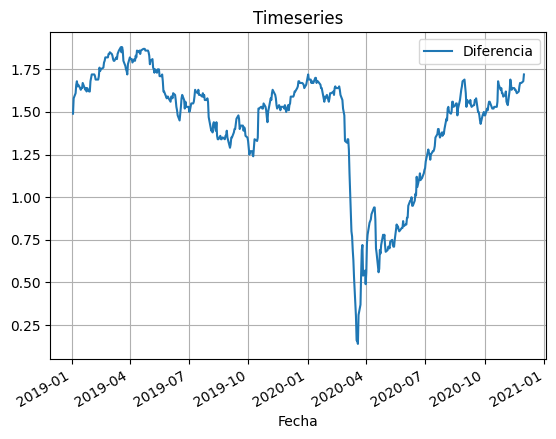

In [8]:
rrm.plot_timeseries_one('EXP_INF_USA5', 'Diferencia', from_date='2019-01-01', to_date='2020-12-01')

A finales de marzo de 2020 la Federal Reserve intervino agresivamente con programas de liquidez y QE ilimitado, había anunciado algo inusual... **Compraría activos (bonos) en la cantidad que fuera necesaria, sin un límite predefinido.** (QE infinito - sin restricción explícita)

La ventana abril–julio captura exactamente ese rebote *desde el mínimo de pánico hasta la estabilización post-QE infinito*, donde **TIPS5 y EXP_INF_USA5 se movieron en perfecta sintonía mientras la Fed anunciaba QE ilimitado y yield curve control implícito**. Muestra entonces la implementación/"resultados" de la intervención más fuerte que hicieron y que se se mantuvo, surtiendo efecto.

A finales de esta ventana, a mediados de 2020 **el mercado envió una señal fuerte de expectativas de inflación más altas, especialmente en horizontes de corto plazo** esto debido a la subida sostenida, menos ruido en liquidez y mejores condiciones de mercado que se habían logrado tras la intervención. 
La señal fue la subida de breakevens (EXP_INF_USA5) de niveles muy bajos a niveles mas altos. *el cual se logra ver dentro del gráfico*

En otras palabras se dice que **esta ventana captura como se desarrolló la intervención mas fuerte que hizo la Fed**, su implementación, donde la liquidez fue restaurada y los precios de mercado volvieron a reflejar fundamentos, permitiendo que las expectativas de inflación y los rendimientos reales se movieran de forma consistente, lo que fortaleció la relación entre ambas variables y permitió como consecuencia una posible lectura del mercado tras su consistencia.

*El R2 de 0.6559 es excepcionalmente alto para datos financieros de alta frecuencia y refleja un régimen de co-movimiento forzado por la intervención de política monetaria sin precedentes.*

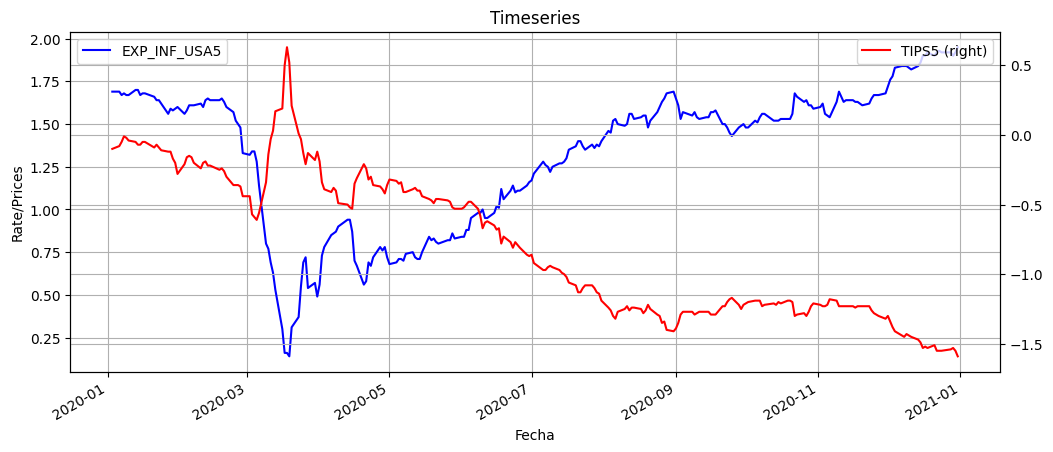

In [11]:

rrm.plot_two_timeseries('EXP_INF_USA5', 'TIPS5', 'Diferencia', 'Tasa', from_date='2020-01-01', to_date='2021-01-01')

Intervenciones... 
* 15 de marzo de 2020
La Federal Reserve baja tasas a 0% y anuncia QE inicial (aprox. 700 mil millones USD), aún NO era “infinito”, *en la gráfica se muestra que ocurre el pico más bajo de la exp. de inflación y el pico mas alto de TIPS5*

Antes del 23 hay ruido extremo

* 23 de marzo de 2020 
Anuncio de QE ilimitado (“infinite QE”). **Este es el verdadero punto de inflexión**
*Lo cual lleva que de abril en adelante el mercaod empiece a normalizarse, lo cual refleja el gráfico*

En resumen...
Marzo 2020 - Pánico total
Finales de marzo - Intervención de la FED agresivamente, anuncio de QE ilimitado y programas de liquidez
Abril–julio - Rebote/resultados de su intervención, el cual fue la estabilización

En crisis (marzo):
TIPS5 - Distorsionado por liquidez - TIPS caen porque nadie quiere liquidez
EXP_INF - Colapsa artificialmente - Breakeven cae fuerte
Causando así que NO hay relación limpia entre ellos, bajo R2

En abril–julio (post QE): La Fed interviene fuerte y el mercado se "estabiliza"
Causando que la liquidez regresara, el mercado funciona mejor, TIPS y EXP_INF reaccionan coherentemente - Se alinean y entonces TIPS5 y EXP_INF empiezan a reflejar lo mismo... expectativas reales de inflación + política monetaria

In [28]:
imprimir_detalles_analisis(complemento_2020, "RESULTADOS COMPLEMENTO 2020")


                     RESULTADOS COMPLEMENTO 2020                      

📌 SECURITY: DXY | Benchmark: TIPS5
   Presencia: 8 de 16 obs. (50.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.0901 [r: -0.3002] (Score: 0.4014)
      Periodo: 2020-05-01 a 2020-09-01
   📈 Max R2: 0.1583 [r: -0.3979] (Score: 0.6610)
      Periodo: 2020-07-01 a 2020-10-01

📌 SECURITY: USDMXN | Benchmark: EXP_INF_USA5
   Presencia: 24 de 24 obs. (100.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.1142 [r: 0.3379] (Score: 0.5722)
      Periodo: 2020-03-02 a 2020-10-01
   📈 Max R2: 0.2194 [r: 0.4684] (Score: 0.9090)
      Periodo: 2020-01-02 a 2020-04-01



**Complemento** 
DXY: 
**Posterior a la ventana de intervención de la FED...(Julio 2020 - Octubre2020)**
Presencia solo 50% (8/16), R² bajo (máx 0.1583). Aquí aparece la primera señal interesante: el DXY no fue un buen seguidor de las expectativas inflacionarias en 2020, a pesar de que **teóricamente el dólar debería debilitarse cuando suben las expectativas de inflación real y a fortalecerse cuando la tasa real de Estados Unidos aumenta, lo que a menudo se refleja en un incremento en el rendimiento (yield) de los TIPS**.

Esto se explica porque **el DXY en 2020 estuvo dominado por flujos de refugio** (safe haven) más que por diferenciales de inflación. 
DXY NO se explicó por fundamentales como inflación/tasas, sino por miedo, provocando movimiento de dinero hacia activos seguros, principalemnte USD.

Más desarrollado, esto último sucede de la siguiente manera:

*En un shock como el COVID-19 market crash GLOBAL, venden activos riesgosos (acciones, emergentes), buscan liquidez*, **compran dólares y bonos de EUA (Bonos nominales del Tesoro, más líquidos que TIPS los cuales se venden o no se compran tanto en crisis) y todo esto genereal demanda masiva por USD y entonces sube el DXY**

---


USDMXN:
*Teoricamente, en un mundo ideal... si suben expectativas de inflación en EUA entonces el dólar debería depreciarse, pero en el mundo real esto casi nunca se cumple limpio porque el FX depende de tasa reales, diferenciales de tasas, riesgo, flujos.*

KEY: 
**Entonces el dólar NO reacciona de forma directa y estable con la inflación, reacciona a tasas reales, diferenciales (tasas EUA − tasas México) y política moentaria.**

Pero en este caso, el USDMXN capturó mejor la señal inflacionaria que sucedia antes de la crisis y durante la crisis, **porque el peso es más sensible al apetito por riesgo que el DXY ponderado por divisas desarrolladas.** Dicha relación entre el USDMXN y la inflación esperada por lo mencionado anteriormente no será estable y no es directa asi que hay que tener cuidado con las interpretaciones.

Risk off - Inversores, impulsados por el miedo, la incertidumbre o tensiones geopolíticas, venden activos de alto riesgo (como acciones) y compran activos seguros ("refugio"), sale capital de México, se vende el peso lo cual provoca subida de USDMXN fuerte.

A diferencia de Risk on - Apetito de riesgo, optimismo económico y confianza, lo que lleva a los inversores a comprar activos de mayor riesgo y rentabilidad potencial. Durante esta fase, el capital fluye hacia acciones, divisas emergentes y materias primas, provocando generalmente tendencias alcistas en los mercados bursátiles, hay optimismo, entra capital, el peso se aprecia y el USDMXN baja.

*Por eso se dice que el peso es un proxy de apetituo por el riesgo Y ES MÁS SENSIBLE QUE EL DXY*

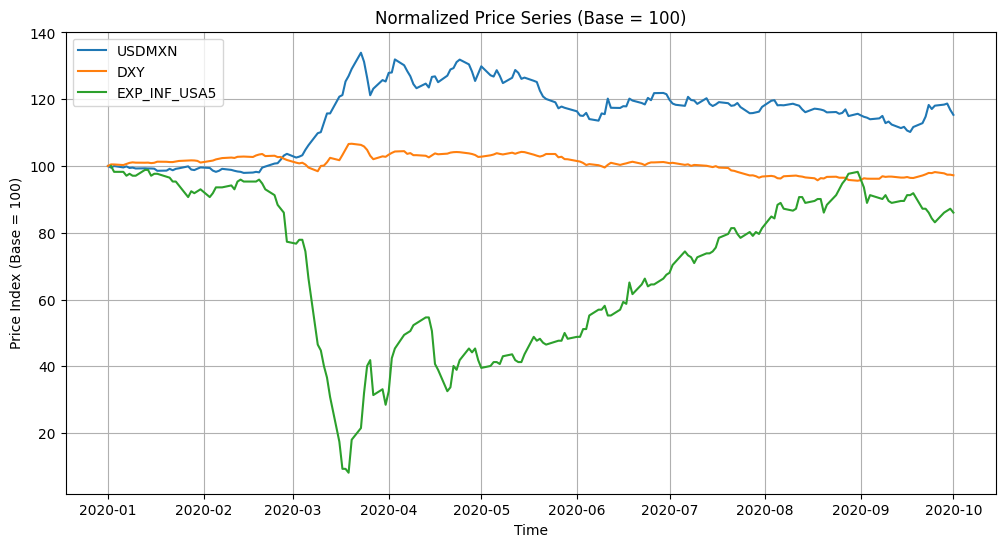

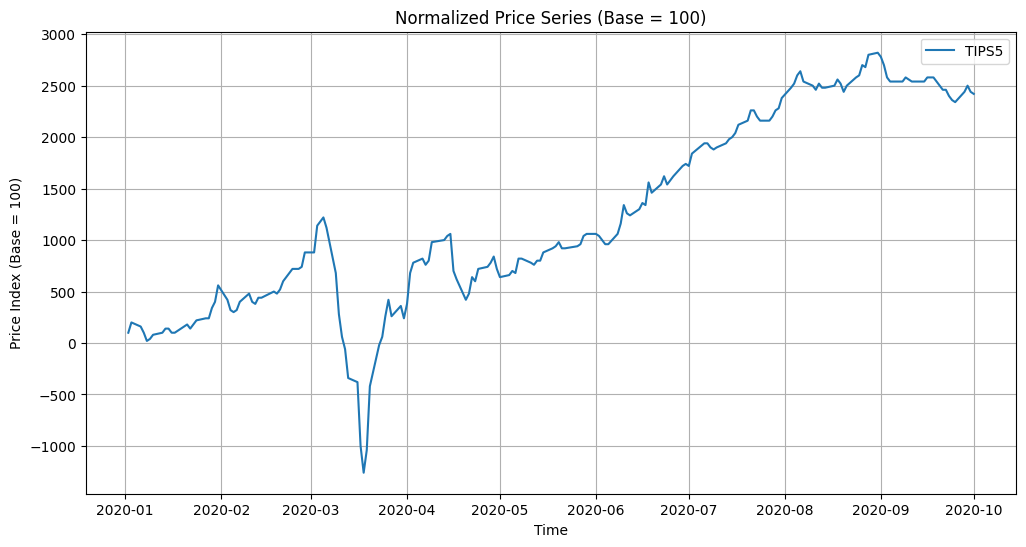

In [ ]:
rrm.plot_normalized_timeseries(['USDMXN', 'DXY', 'EXP_INF_USA5'], ['Cierre', 'Cierre', 'Diferencia'], from_date='2020-01-01', to_date='2020-10-01')

La subida en marzo de 2020 del DXY y del USDMN es por razones distintas... DXY por refugio global y USDMXN por salida de capital mas riesgo por la crisis presente, lo cual es el risk off que mencionabamos haciendo más sensible y por ende más fuerte la depreciación del peso.

## 2023 Régimen de Desinflación: El DXY Toma el Liderazgo
Key: Expectativas del Mercado.
Capturó: Expectativas de política monetaria vía tasas reales

In [89]:
r2_2023 = buscar_mejor_r2(x = benchmarks_x, y = securities_y, start_date='2023-01-01', end_date='2023-12-31')

In [90]:
analizar_temporalidad_lider(r2_2023)

--- ANÁLISIS ESTRUCTURAL PARA DXY vs TIPS5 ---
Mejor periodo detectado (R2 ponderado): 2023-01-03 a 2023-12-01
R2 en este periodo: 0.2974 (332 días)
Mes con mayor recurrencia en el análisis: June


,security,benchmark,r2,correlation,beta,from,to,n_obs,score,duracion_dias,score_temporal
1,DXY,TIPS5,0.297444,-0.545384,-0.439599,2023-01-03 00:00:00,2023-12-01 00:00:00,231,1.618814,332,98.751408


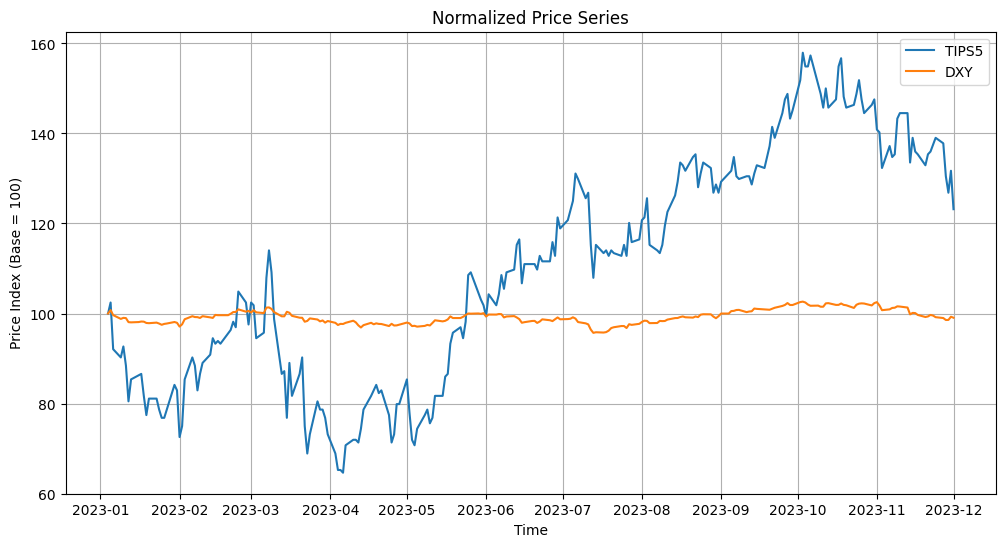

In [112]:
rrm.plot_normalized_timeseries(['TIPS5', 'DXY'], from_date='2023-01-03', to_date='2023-12-01')

In [10]:
imprimir_resumen_frecuencias(r2_2023)

Conteo de securities: security
DXY             45
USDMXN          19
EXP_INF_USA5     1
Name: count, dtype: int64 

El security (y) más frecuente es: DXY
Aparece 45 veces de un total de 65 (69.23%)
Del security 'DXY', su benchmark (x) más frecuente es 'TIPS5' (45 veces)

Mejor registro por Score:
Sec: DXY | Bench: TIPS5 | Score: 1.6833 | R2: 0.3364 | Periodo: 2023-05-01 a 2023-12-01


In [11]:
principal_2023, complemento_2023 = analizar_securities(r2_2023)

imprimir_detalles_analisis(principal_2023, "RESULTADOS PRINCIPAL 2023")


                      RESULTADOS PRINCIPAL 2023                       

📌 SECURITY: DXY | Benchmark: TIPS5
   Presencia: 45 de 45 obs. (100.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.1878 [r: -0.4333] (Score: 0.7839)
      Periodo: 2023-08-01 a 2023-11-01
   📈 Max R2: 0.3884 [r: -0.6232] (Score: 1.6151)
      Periodo: 2023-05-01 a 2023-08-01



**Principal**: 
DXY explicado por TIPS5. Presencia 45/45 (100%) y R2 máximo de 0.3884 en mayo–agosto.
En 2023 la FED tenía una política restrictiva.

*¿Qué explica esto?*
**2023 fue el año de transición entre el pico inflacionario (9.1% CPI en jun 2022) y la desinflación progresiva**. 
*El breakeven a 5 años alcanzó su máximo de 3.6% en marzo de 2022 y cayó por debajo del 2.5% a mediados de 2023 mientras la inflación subyacente se desaceleraba.*

La situación era restrictiva.

<Figure size 640x480 with 0 Axes>

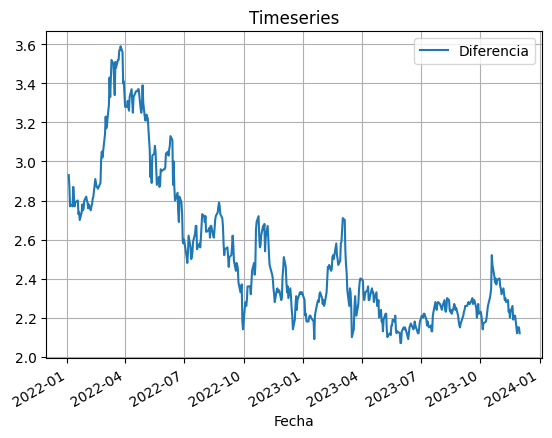

In [7]:
rrm.plot_timeseries_one('EXP_INF_USA5', 'Diferencia', from_date='2022-01-01', to_date='2023-12-01')

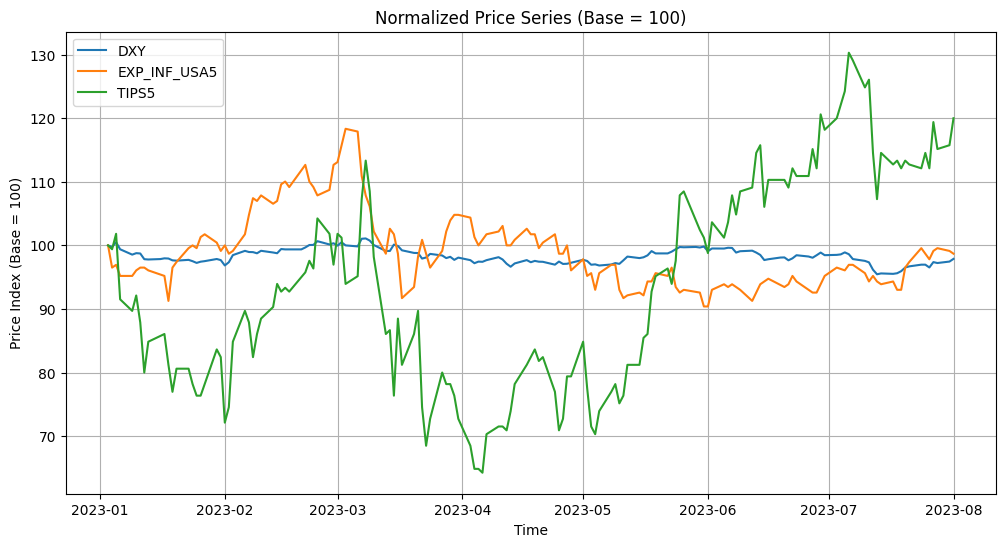

In [6]:
rrm.plot_normalized_timeseries(['DXY', 'EXP_INF_USA5', 'TIPS5'],['Cierre', 'Diferencia', 'Tasa'], from_date='2023-01-01', to_date='2023-08-01')

**Desinflación + política restrictiva = tasas reales altas**

**Un TIPS5 cayendo implica menor inflación implícita** y entonces mayor probabilidad de pivot dovish es decir, dólar más débil. Como se observa entre marzo-abril de 2023.

La ventana mayo–agosto 2023 coincide con el **período en que el mercado apostó más agresivamente por recortes de la Fed (que nunca llegaron en 2023, observa que TIPS sigue a la alza)**, creando un movimiento coordinado y explicable entre ambas variables al inicio, pues posteriormente se anticiparia un corte visto que el breakeven (inflación esperada) por su parte seguía cayendo...

Entonces, la señal de movimientos en tasas reales (a la alza) consistentes con desinflación esperada se transmitía directamente al DXY **porque los mercados estaban recalibrando las expectativas de recorte de tasas.**Es decir, el mercado empezaba a anticipar que la inflación bajaba, pero que la Fed eventualmente tendría que recortar tasas y por ende causar que el dolar se debilitara... esto podría verse entre Junio y Julio de 2023.

Dicha expectativa cumplió su cometido, tal que cuando TIPS5 'cayó', el mercado ya lo había anticipado con su expectativa (observese como 'caía' DXY antes de la primera 'caída' de TIPS5 a inicios de septiembre 2025).

Posterior a ese punto de agosto 2023 la exp. de inflación subió implicando la alza de tasas reales y por ende la de DXY tambien, mostrando de nuevo su comportamiento natural... pero ahora sin expectativas.

*Y es clave, porque uno puede seguir la regla de que tasas reales mas altas implican que el dolar se fortalece en sincronía sin más, lo cual sería incorrecto y esta ventana muestra como el mercado anticipa/ve que algo puede llegar a su fin con la comibnación de otras variables macro (en este caso el breakwven) y afectar a la otra variable implicada (DXY).*

Movimientos de DXY - Explicadods por tasas reales + breakeven, la advertencia fue la sincronía inversa que estos tenían para anticipar la posible caída del DXY.

El cambio clave respecto a 2018 y 2020: 

EXP_INF_USA5 ya no es la principal, sino un complemento débil (R2 0.1101, una sola observación). *Esto indica que en 2023 las expectativas de encuesta y las de mercado divergieron*: **el mercado de TIPS5 ya descontaba la desinflación** mientras las encuestas todavía registraban expectativas elevadas. El DXY como activo de mercado siguió al TIPS5 con mayor fidelidad que EXP_INF_USA5.

**Los movimientos en tasas reales reflejaban un cambio en las expectativas de política monetaria, donde la desinflación permitió al mercado anticipar futuros recortes de tasas, generando una relación inversa con el DXY.**

In [12]:
imprimir_detalles_analisis(complemento_2023, "RESULTADOS COMPLEMENTO 2023")


                     RESULTADOS COMPLEMENTO 2023                      

📌 SECURITY: EXP_INF_USA5 | Benchmark: TIPS5
   Presencia: 1 de 1 obs. (100.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.1101 [r: 0.3319] (Score: 0.4563)
      Periodo: 2023-04-03 a 2023-06-30
   📈 Max R2: 0.1101 [r: 0.3319] (Score: 0.4563)
      Periodo: 2023-04-03 a 2023-06-30

📌 SECURITY: USDMXN | Benchmark: TIPS5
   Presencia: 16 de 19 obs. (84.21%)
   -----------------------------------------------------------------
   📉 Min R2: 0.0998 [r: -0.3159] (Score: 0.4985)
      Periodo: 2023-04-03 a 2023-11-01
   📈 Max R2: 0.3147 [r: -0.5610] (Score: 1.3038)
      Periodo: 2023-09-01 a 2023-12-01



In [29]:
# Demostremos la facilidad de nuestro código para crear herramientas que no teníamos disponibles.
diferencial_nominal = rrm.synchronise_timseries_df('BONOM5', 'DGS5', 'Cierre', 'Tasa', dif = True)
rrm.cargar_archivo(diferencial_nominal, archivo = 'DIF_NOM')

Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/DIF_NOM.csv
Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/PROXI.csv


**Key: El mismo modelo que estamos desarrollando nos dice que no es del todo eficiente para entender el mercado, lo cual es claro y no es el propósito del modelo, su propósito es que nos muestre estas 'ineficiencias' bajo más contexto económico.**

**Complemento:** 
USDMXN: presencia 84.21% (16/19), benchmark líder ahora es **TIPS5 directamente** (no EXP_INF_USA5 como en 2020). R2 máximo de 0.3147 en septiembre–diciembre.

Recuerda TIPS captura política monetaria y el breakeven captura inflación.

**Contexto de 2023:**

**La apreciación del peso en 2023 se explicó en gran parte por el diferencial de tasas entre México y EE.UU., que incentivó estrategias de carry trade.** Esto estuvo presente únicamente a inicios de 2023 (enero-abril), donde el diferencial crecía y en parte decrecía USDMXN (esta última ventana mencionada no lo capturó nuestro codigo porque no usamos la data de diferencial de tasa entre México y EE.UU. dentro del proceso de búsqueda - *lo cual nos lleva a cuestionar el proceso de no usar la data de México en todo el análisis de Estados Unidos*).

*Es claro a este punto que el diferencial no fue el único factor que explicó la apreciación del peso, de hecho fue unicamente para 2023, ya que la apreciación del peso venía sucediendo desde mucho más antes (julio-septiembre 2022)*


*Carry Trade: Inversionistas piden prestado en una moneda con baja tasa (USD) e invierten en una con alta tasa (MXN) para capturar el diferencial.*

Entonces la apreciación del peso (USDMXN baja) debido a que Banxico ofrecía tasas altas y la FED mas baja o espectativas de bajadas, entra capital a México.

Bajo ese periodo de apreciación debió observarse...
* Inflación en México más persistente
* Política restrictiva de Banxico
* Expectativas de que la Fed iba a recortar

La importancia de esto, el USDMXN no se explica con una sola variable en el tiempo, el diferencial entre tasas es una.


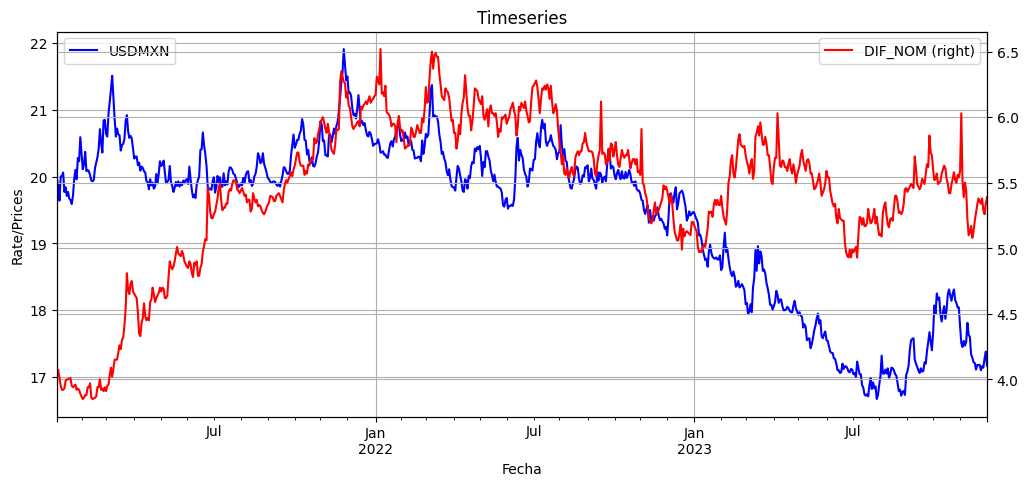

In [46]:
rrm.plot_two_timeseries('USDMXN', 'DIF_NOM', 'Cierre', 'Diferencia', from_date='2021-01-01', to_date='2023-12-01')



**El TIPS5 cayendo (menor inflación esperada en EE.UU.)** entonces expectativa de Fed pivot (*Pivot = cambio de postura, de... bajo este contexto, de subir tasas a pausar o bajar tasas*) y entonces influjos al peso es decir, la entrada de capital hacia activos mexicanos que requiere comprar pesos MXN (un extranjero para invertir en México vende dólares, compra pesos, invirte en instrumentos como BONOS M, acciones, proyectos/nearshoring, lo cual genera demanda por pesos).

La presencia del 84% confirma una **relación robusta pero no perfecta**, lo cual es consistente con que el superpeso de 2023 también tuvo factores propios (nearshoring, remesas), en otras palabras más claras... **La relación es fuerte (84%), pero no perfecta, porque el peso también se fortaleció por razones propias de México, no solo por lo que pasaba en EE.UU.**

Es decir, *la caída en tasas reales (TIPS5) reflejó expectativas de un posible giro (pivot) en la política de la Fed, lo que redujo el atractivo del dólar y favoreció flujos hacia monedas emergentes como el peso mexicano.* (semptiembre-diciembre)

**CONCLUSIÓN CLAVE** y que nos hace tener cuidado con el uso de este modelo y las interpretaciones subyacentes de este mismo...
El modelo (TIPS5 -> expectativas de Fed -> flujos -> peso) explica gran parte de la apreciación del USD/MXN en 2023, **pero no toda**. La apreciación del peso en 2023 no se explicó únicamente por movimientos en tasas reales (TIPS), sino por la combinación de desinflación en EE.UU., expectativas de un giro en la política monetaria de la Fed y un *diferencial de tasas favorable a México*, lo que incentivó flujos de carry trade hacia el peso.

*En el gráfico de abajo solo muestra en parte el impacto de TIPS5 (y de otros factores que se involucraron), el USDMXN venía cayendo desde finales de 2020 hasta agosto de 2023, posterior a esta fecha vendría el impacto de TIPS5*

PERO QUE SUCEDE
*TIPS5 con USDMXN suelen tener comportamientos proporcionales/similares*
El modelo nos da una correlación negativa, con bajo r2...

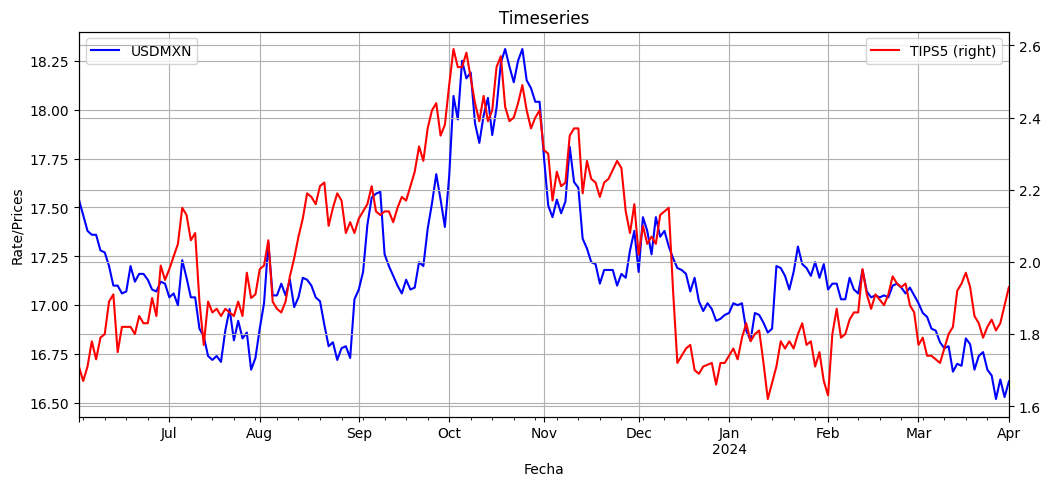

In [52]:
rrm.plot_two_timeseries('USDMXN', 'TIPS5', 'Cierre', 'Tasa', from_date='2023-06-01', to_date='2024-04-01')

## 2025 — Señal Mixta: Incertidumbre Arancelaria Fragmenta las Relaciones
Key - complemento: Dominio de TIPS vs EXP_INF en el dolar, ¿Cuándo sucede?
Distorsión = el precio de mercado deja de reflejar principalmente el fundamento que debería medir.
TIPS debería reflejar tasas reales
Breakeven (EXP_INF) debería reflejar inflación esperada
Pero en la práctica incluyen liquidez, flujos, primas de riesgo que podrían distorcionarlos.
Cuando una variable se distorsiona, pierde poder explicativo relativo tal que otra variable puede explicar mejor al FX.

In [111]:
r2_2025 = buscar_mejor_r2(x = benchmarks_x, y = securities_y, start_date='2025-01-01', end_date='2026-04-01')

In [237]:
r2_2025.head(10)
# security	benchmark	r2	correlation	beta	from	to	n_obs	score
# 216	USDMXN	EXP_INF_USA5	0.200512	0.447786	0.452674	2025-04-01	2025-07-01	63	0.830748

,security,benchmark,r2,correlation,beta,from,to,n_obs,score
0,DXY,TIPS5,0.282829,-0.531817,-0.750940,2025-08-01,2025-10-31,64,1.176253
1,DXY,TIPS5,0.254334,-0.504316,-0.740979,2025-07-01,2025-10-01,65,1.061689
2,DXY,TIPS5,0.232478,-0.482160,-0.668597,2025-08-01,2025-12-01,83,1.027283
3,DXY,TIPS5,0.213764,-0.462347,-0.627149,2025-08-01,2025-12-31,104,0.992804
4,DXY,TIPS5,0.217420,-0.466284,-0.663528,2025-07-01,2025-10-31,86,0.968464
5,DXY,TIPS5,0.192058,-0.438244,-0.651010,2025-05-01,2025-10-01,106,0.895651
6,DXY,TIPS5,0.187968,-0.433553,-0.609114,2025-07-01,2025-12-01,105,0.874796
7,DXY,EXP_INF_USA5,0.210247,-0.458527,-0.731417,2025-01-02,2025-04-01,62,0.867718
8,DXY,TIPS5,0.179112,-0.423216,-0.618429,2025-05-01,2025-10-31,127,0.867652
9,DXY,TIPS5,0.175748,-0.419223,-0.579958,2025-07-01,2025-12-31,126,0.849967


In [56]:
imprimir_resumen_frecuencias(r2_2025)

Conteo de securities: security
DXY       60
USDMXN    13
Name: count, dtype: int64 

El security (y) más frecuente es: DXY
Aparece 60 veces de un total de 73 (82.19%)
Del security 'DXY', su benchmark (x) más frecuente es 'TIPS5' (43 veces)

Mejor registro por Score:
Sec: DXY | Bench: TIPS5 | Score: 1.1763 | R2: 0.2828 | Periodo: 2025-08-01 a 2025-10-31


In [57]:
principal_2025, complemento_2025 = analizar_securities(r2_2025)
imprimir_detalles_analisis(principal_2025, "RESULTADOS PRINCIPAL 2025")


                      RESULTADOS PRINCIPAL 2025                       

📌 SECURITY: DXY | Benchmark: TIPS5
   Presencia: 43 de 60 obs. (71.67%)
   -----------------------------------------------------------------
   📉 Min R2: 0.0950 [r: -0.3082] (Score: 0.4420)
      Periodo: 2025-04-01 a 2025-08-29
   📈 Max R2: 0.2828 [r: -0.5318] (Score: 1.1763)
      Periodo: 2025-08-01 a 2025-10-31



**Principal**: 
DXY explicado por TIPS5, pero presencia cae a 71.67% (43/60). R2 máximo de 0.2828 en agosto–octubre.
La caída de presencia al 71% respecto al 100% de 2023 es la señal más importante de 2025. 

La inflación anual en EE.UU. se mantuvo en 2.4% en febrero de 2026, en su nivel más bajo desde mayo de 2025, **lo que sugiere que durante 2025 hubo volatilidad en el proceso de desinflación.**

**Los aranceles de la administración Trump reintrodujeron ruido estructural en la relación TIPS5-DXY**: el mercado no podía discernir si el DXY se fortalecía por safe haven (aranceles = proteccionismo = dólar fuerte) o se debilitaba por inflación importada (aranceles = precios más altos = menos credibilidad de la Fed). Esta ambigüedad reduce la R2 sistemáticamente.

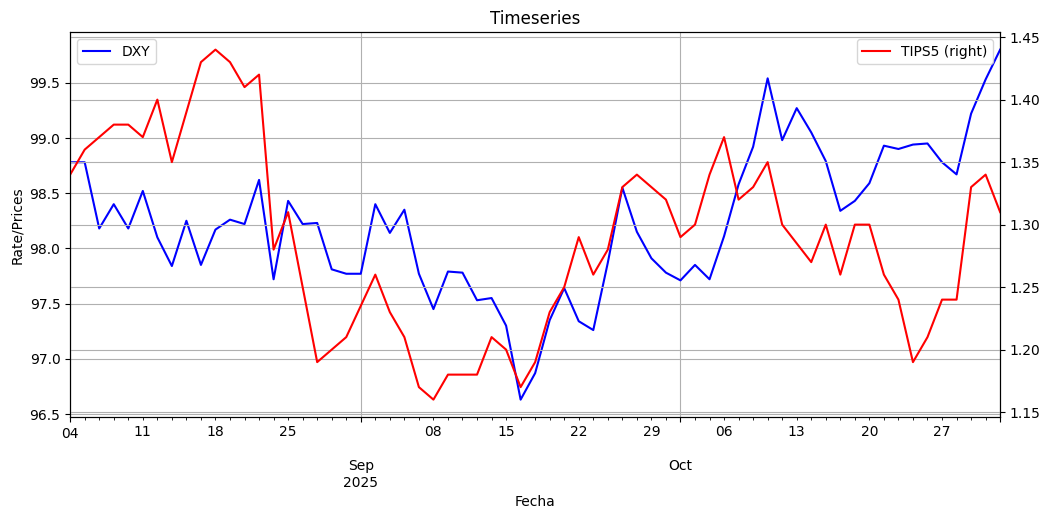

In [58]:
rrm.plot_two_timeseries('DXY', 'TIPS5', 'Cierre', 'Tasa', from_date='2025-08-01', to_date='2025-10-31')

In [59]:
imprimir_detalles_analisis(complemento_2025, "RESULTADOS COMPLEMENTO 2025")


                     RESULTADOS COMPLEMENTO 2025                      

📌 SECURITY: USDMXN | Benchmark: EXP_INF_USA5
   Presencia: 13 de 13 obs. (100.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.0901 [r: 0.3002] (Score: 0.4612)
      Periodo: 2025-04-01 a 2025-12-01
   📈 Max R2: 0.2005 [r: 0.4478] (Score: 0.8307)
      Periodo: 2025-04-01 a 2025-07-01



**Complemento**
USDMXN: benchmark es EXP_INF_USA5, presencia 13/13 (100%). **El USDMXN vuelve a ser perfectamente explicado por las expectativas de inflación americana, pero ahora a través de EXP_INF_USA5 en lugar de TIPS5.** 

Esto podría indicar que el mercado de tipo de cambio en 2025 *siguió más las expectativas de inflación “más limpias” o consensos (encuestas/modelos) que el precio de mercado de los TIPS*, posiblemente por que TIPS estaban más distorsionados que los breakevens ya que la volatilidad política tiende a distorsionar más a la tasa de interés real que a las expectativas de inflación, principalmente porque *la tasa real absorbe directamente el impacto de la incertidumbre en los mercados financieros, el tipo de cambio y el riesgo país*, elementos que reaccionan más rápido que las proyecciones de precios a largo plazo, o el mercado FX estaba reaccionando a narrativa inflacionaria más que a tasas reales

*Distorsión = el precio de mercado deja de reflejar principalmente el fundamento que debería medir.*

Key:
**Si el tipo de cambio está siendo explicado por movimientos en tasas reales de EE.UU., lo que sugiere que el mercado está reaccionando principalmente a condiciones financieras globales y a la postura de la Federal Reserve, más que a expectativas puras de inflación.** Es decir, costo del dinero y política monetaria.

**La acción de la Fed** cambia qué variable contiene la señal dominante. Entonces NO es que la FED hace que la inflación sea ruidosa y generalizarlo de esa forma, si no que la Fed hace que las tasas reales se vuelvan el canal dominante de transmisión.

*En 2023 el mercado no preguntó “¿cuánta inflación habrá?” sino “¿qué tan restrictiva será la Fed?” - afectando/involucrando a TIPS como canal dominante pues la inflación estaba bajando pero la FED seguía subiendo o manteniendo tasas (política monetaria)*

Claro está que no podemos asumir automáticamente “distorsión en X entonces el modelo usa Y”, tenemos que ver qué variable explica mejor (R2).

**Escenarios vistos:**
*Escenario A* (inflación domina) - Inflación inesperadamente alta, el mercado ajusta expectativas (entrada de FED, canal dominante = inflación) -> FX sigue breakevens (EXP_INF) - **Pregunta del mercado: “¿Qué pasará con la inflación?”**
*Escenario B* (Fed domina) - Fed sube tasas agresivamente, mercado enfocado en política -> FX sigue TIPS (tasas reales) - **Pregunta del mercado: “¿Qué tan restrictiva será la Fed?”**

*Si el tipo de cambio está explicado por tasas reales, esto indica que el mercado está reaccionando principalmente al costo del dinero y a la postura de la política monetaria, mientras que en otros periodos puede responder más a expectativas de inflación. Ambas dinámicas están vinculadas a la Fed, pero a través de distintos canales de transmisión.*

En 2020, ante la crisis, no había un canal de inflación limpio y tampoco un canal de tasa reales limpio, en el que en ambos no hubiera distorción o ruido... **el canal que dominó fue el canal de liquidez y estrés financiero**. No fue ni TIPS ni EXP_INF.
Es por ello que dentro del proceso de intervención de la fed abril-julio 2020 que buscaba estabilidad, el canal principal fué liquidez.

**2020 es un régimen distinto: no es inflación ni política “normal”, es modo crisis.**

"La dinámica observada en 2020 no responde a un canal puro de inflación ni de tasas reales, sino a un episodio de estrés de liquidez donde las distorsiones en los mercados de bonos (incluyendo TIPS) afectaron las métricas implícitas como los breakevens."

## Análisis 2026 - Semanal 
Explicaciones dentro de intervalos semanales
Debemos de tener cuidado con r^2 grandes o perfectos con observaciones menores a 5
Si mi numero de observaciones mínimas es de 5 (días), entonces estamos analizando el comportamiento máximo posible del r2 que pudo haber entre las variables dentro de una semana 

In [106]:
min_dias_obs = 20 # 5 = una semana, 20 = un mes como mínimio entre rangos
r2_2026 = buscar_mejor_r2(x = benchmarks_x, y = securities_y, freq='W-FRI',start_date='2026-01-01', end_date='2026-04-19', order='r2', min_obs=min_dias_obs, min_corr=0)

In [110]:
analizar_temporalidad_lider(r2_2026)


--- ANÁLISIS ESTRUCTURAL PARA DXY vs EXP_INF_USA5 ---
Mejor periodo detectado (R2 ponderado): 2026-02-13 a 2026-04-16
R2 en este periodo: 0.3499 (62 días)
Mes con mayor recurrencia en el análisis: March


,security,benchmark,r2,correlation,beta,from,to,n_obs,score,duracion_dias,score_temporal
17,DXY,EXP_INF_USA5,0.349876,-0.591503,-0.703432,2026-02-13 00:00:00,2026-04-16 00:00:00,44,1.323997,62,21.692312


In [144]:
imprimir_resumen_frecuencias(r2_2026)

Conteo de securities: security
DXY             88
USDMXN          88
EXP_INF_USA5    45
Name: count, dtype: int64 

El security (y) más frecuente es: DXY
Aparece 88 veces de un total de 221 (39.82%)
Del security 'DXY', su benchmark (x) más frecuente es 'EXP_INF_USA5' (44 veces)

Mejor registro por Score:
Sec: DXY | Bench: EXP_INF_USA5 | Score: 1.0464 | R2: 0.3437 | Periodo: 2026-02-20 a 2026-03-20


In [152]:
principal_2026, complemento_2026 = analizar_securities(r2_2026)
imprimir_detalles_analisis(principal_2026, "RESULTADOS PRINCIPAL 2026")
imprimir_detalles_analisis(complemento_2026, "RESULTADOS COMPLEMENTO 2026")


                      RESULTADOS PRINCIPAL 2026                       

📌 SECURITY: DXY | Benchmark: EXP_INF_USA5
   Presencia: 78 de 156 obs. (50.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.0014 [r: -0.0367] (Score: 0.0049)
      Periodo: 2026-01-09 a 2026-03-06
   📈 Max R2: 0.4209 [r: -0.6487] (Score: 1.4452)
      Periodo: 2026-02-27 a 2026-04-10


                     RESULTADOS COMPLEMENTO 2026                      

📌 SECURITY: EXP_INF_USA5 | Benchmark: TIPS5
   Presencia: 78 de 78 obs. (100.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.0000 [r: 0.0015] (Score: 0.0000)
      Periodo: 2026-02-13 a 2026-04-16
   📈 Max R2: 0.1004 [r: -0.3169] (Score: 0.3008)
      Periodo: 2026-01-02 a 2026-01-30

📌 SECURITY: USDMXN | Benchmark: EXP_INF_USA5
   Presencia: 78 de 156 obs. (50.00%)
   -----------------------------------------------------------------
   📉 Min R2: 0.0004 [r: -0.0198] (Score: 0.0015)


Principal: DXY explicado por EXP_INF_USA5 (no TIPS5). Presencia cae a 50% (44/88). R² oscila desde casi cero (0.0014) hasta 0.3437 en ventanas muy específicas.
Este es el resultado más alarmante del conjunto. Tres señales críticas:

1. El benchmark líder cambia de TIPS5 a EXP_INF_USA5. Esto sugiere que en las últimas semanas los TIPS han dejado de ser el ancla dominante del DXY, posiblemente porque la volatilidad de los breakevens en 2026 (incertidumbre arancelaria extrema, riesgo de recesión) *los hace menos informativos*. El breakeven a 5 años se ubicaba en 2.61% en abril de 2026, nivel elevado dado el entorno, lo que implica que el **mercado sigue con expectativas inflacionarias pero sin dirección clara**.

2. El R2 mínimo es prácticamente cero (0.0014, Score 0.0049) en la ventana enero 9 – marzo 6. Esto indica que durante ese período el DXY se movió de forma completamente desconectada de las expectativas de inflación, un régimen que típicamente ocurre en episodios de risk-off extremo (y entonces beneficiandose el dolar) o disrupción de política monetaria donde el dólar se mueve por flujos de refugio puro.

3. EXP_INF_USA5 como complemento muestra R2 de 0.0000 en algunas ventanas de 2026. *La relación entre expectativas de inflación y TIPS prácticamente se desintegró en ciertos períodos recientes, consistente con la disrupción causada por la guerra arancelaria y la incertidumbre sobre el rumbo de la Fed*.

En palabras más claras:
Sí hay relación importante entre el dolar y el breakeven pero 60-66% queda sin explicar (otros factores: tasas reales, petróleo, expectativas, política monetaria, etc.).

Aquí conviene no forzarlo al “canal inflacionario” directamente.

Como bien mencionamos, lo que pudo haber sucedido antes de que pudiera el dolar poder explicarse en parte por la inflación, es una situación de Risk-off (canal primario) y entonces búsqueda de refugio lo cual provoca flujos hacia USD, entonces sube DXY y sube USD/MXN (se deprecia el peso).

Posterior a ello, vendría el canal secundario (después) que puede afectar a la inflación (energía, commodities), crecimiento y política monetaria de la Federal Reserve.

El canal inflacionario es indirecto... 
Guerra -> sube petróleo -> Mercado espera más inflación -> sube EXP_INF

El mercado FX está reaccionando a expectativas macro (incluyendo inflación) generadas por el shock geopolítico.

Pero ojo, los r2 obtenidos...
0.33 (USDMXN)
0.34 (DXY)
Son moderados / bajos, lo cual nos dice que *no hay un solo canal dominante y al menos podemos descartar TIPS / tasas reales que ha sido uno de los principales junto con el breakeven dentro de nuestro breve e informal análsis* 

En resumen, la cadena causal más realista es... sucede el evento geopolítico y entonces aumenta incertidumbre, esa incertidumbre causa flujos de resguardo impulsados por el miedo, la incertidumbre y/o tensiones geopolíticas, venden activos de alto riesgo (como acciones) y compran activos seguros ("refugio") (risk-off)
Posteriormente sucede el ajuste en expectativas tanto de inflación, crecimiento, política monetaria y entonces el FX reacciona, lo cual explica que el canal inflacionario es parcial, no puro o dominante.

Resumen en corto: 
*El comportamiento del tipo de cambio en este periodo parece estar influenciado por un shock geopolítico que afectó tanto el apetito por riesgo como las expectativas macroeconómicas, incluyendo inflación, lo que explica que variables como EXP_INF_USA5 tengan cierta capacidad explicativa, aunque sin dominar completamente la dinámica del mercado.*

**Los shocks geopolíticos no activan un solo canal, activan varios al mismo tiempo.**

## Anual 2018-2026

In [153]:
annual = buscar_mejor_r2(x = benchmarks_x, y = securities_y, start_date='2018-01-01', end_date='2026-04-01', min_obs=250, min_corr=0.2, freq='AS-JAN')
# el parametro min_obs SIEMPRE hará alusión a dias mínimos entre intervalos de tiempo, cambiemos o no la frecuencia a anual, mensual o diaria.


/var/folders/kz/rybrs64563zc2gl94rf00qbw0000gn/T/ipykernel_37887/672580790.py:22: FutureWarning: 'AS-JAN' is deprecated and will be removed in a future version, please use 'YS-JAN' instead.
  fechas = pd.date_range(start=start_date, end=end_date, freq=freq)  # Monthly Start, esto crea bloques de fechas mensuales... 2018-01-01, 2018-02-01, 2018-03-01, ... etc


In [154]:
analizar_temporalidad_lider(annual)

--- ANÁLISIS ESTRUCTURAL PARA DXY vs TIPS5 ---
Mejor periodo detectado (R2 ponderado): 2018-01-03 a 2025-12-31
R2 en este periodo: 0.1169 (2919 días)
Mes con mayor recurrencia en el análisis: February


,security,benchmark,r2,correlation,beta,from,to,n_obs,score,duracion_dias,score_temporal
33,DXY,TIPS5,0.116941,-0.341967,-0.000243,2018-01-03 00:00:00,2025-12-31 00:00:00,1998,0.88874,2919,341.350779


In [165]:
imprimir_resumen_frecuencias(annual)

Conteo de securities: security
DXY             36
EXP_INF_USA5    27
USDMXN          15
Name: count, dtype: int64 

El security (y) más frecuente es: DXY
Aparece 36 veces de un total de 78 (46.15%)
Del security 'DXY', su benchmark (x) más frecuente es 'TIPS5' (33 veces)

Mejor registro por Score:
Sec: DXY | Bench: TIPS5 | Score: 1.8194 | R2: 0.2928 | Periodo: 2023-01-03 a 2024-12-31


In [166]:
principal_annual, complemento_annual = analizar_securities(annual)
imprimir_detalles_analisis(principal_annual, "RESULTADOS PRINCIPAL ANUAL")
imprimir_detalles_analisis(complemento_annual, "RESULTADOS COMPLEMENTO ANUAL")


                      RESULTADOS PRINCIPAL ANUAL                      

📌 SECURITY: DXY
   Benchmark Líder: TIPS5
   Presencia: 33 de 36 obs. (91.67%)
   -------------------------------------------------------
   📉 Min R2: 0.0437  (Score: 0.2711)
      Periodo: 2018-01-03 a 2019-12-31
   📈 Max R2: 0.3143  (Score: 1.7354)
      Periodo: 2023-01-03 a 2023-12-29


                     RESULTADOS COMPLEMENTO ANUAL                     

📌 SECURITY: EXP_INF_USA5
   Benchmark Líder: TIPS5
   Presencia: 27 de 27 obs. (100.00%)
   -------------------------------------------------------
   📉 Min R2: 0.0492  (Score: 0.3397)
      Periodo: 2022-01-03 a 2025-12-31
   📈 Max R2: 0.4393  (Score: 2.4271)
      Periodo: 2020-01-02 a 2020-12-31

📌 SECURITY: USDMXN
   Benchmark Líder: EXP_INF_USA5
   Presencia: 8 de 15 obs. (53.33%)
   -------------------------------------------------------
   📉 Min R2: 0.0405  (Score: 0.2683)
      Periodo: 2020-01-02 a 2022-12-30
   📈 Max R2: 0.1149  (Score: 0.6348)
  

Principal anual: DXY explicado por TIPS5, presencia 91.67% (33/36 ventanas). R2 máximo de 0.3143 en el año 2023 completo. R² mínimo de 0.0437 en 2018–2019.
Esto corrobora que 2023 fue el año de mayor coherencia estructural entre las expectativas de inflación de mercado y el dólar que fue el año donde la Fed tuvo mayor credibilidad en su narrativa desinflacionaria y los mercados operaron con mayor predictibilidad.

Complemento anual — EXP_INF_USA5: presencia 27/27 (100%), R2 máximo de 0.4393 en 2020 completo. Esto confirma que 2020 fue el año de mayor poder explicativo de las expectativas de inflación sobre activos financieros, explicado por el régimen de intervención masiva de la Fed que sincronizó todos los indicadores de inflación esperada.

********** Resultados desde 2020-01-02 hasta 2020-12-31 **********


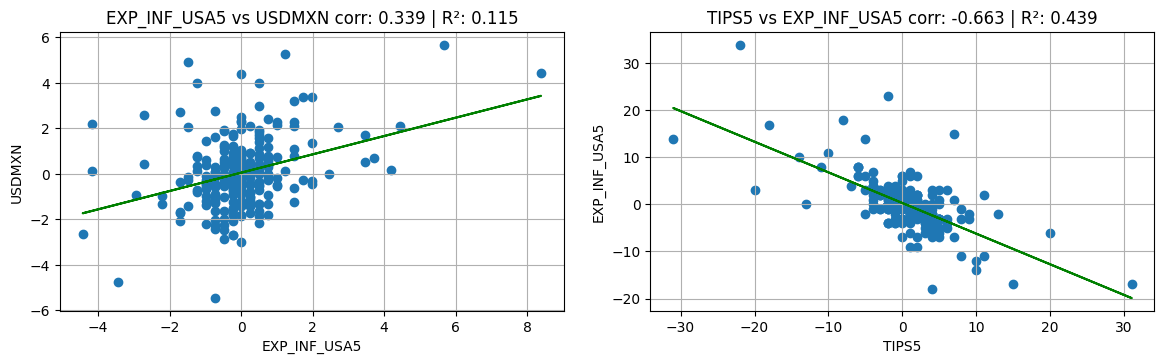

       security     benchmark      beta  correlation        r2
2        USDMXN  EXP_INF_USA5  0.402792     0.338939  0.114880
0           DXY  EXP_INF_USA5  0.033058     0.039647  0.001572
3        USDMXN         TIPS5 -0.157193    -0.093553  0.008752
1           DXY         TIPS5 -0.290354    -0.246290  0.060659
4  EXP_INF_USA5         TIPS5 -0.651805    -0.662766  0.439259


In [ ]:
data_1826 = get_data(x = benchmarks_x, y = securities_y, from_date='2020-01-01', to_date='2020-12-31')
print(data_1826)

********** Resultados desde 2024-01-02 hasta 2026-04-02 **********


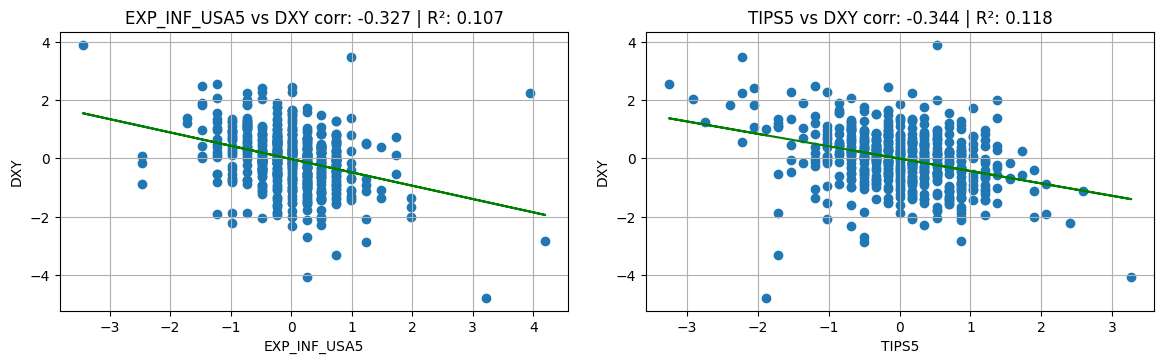

       security     benchmark      beta  correlation        r2
2        USDMXN  EXP_INF_USA5  0.144063     0.111195  0.012364
4  EXP_INF_USA5         TIPS5  0.035248     0.056761  0.003222
3        USDMXN         TIPS5 -0.140703    -0.121211  0.014692
0           DXY  EXP_INF_USA5 -0.456381    -0.327195  0.107056
1           DXY         TIPS5 -0.425596    -0.343990  0.118329


In [155]:
data_2526 = get_data(x = benchmarks_x, y = securities_y, from_date='2024-01-01')
print(data_2526)

In [156]:
data_2026 = get_data(x = benchmarks_x, y = securities_y, from_date='2026-01-01')
print(data_2026)

********** Resultados desde 2026-01-02 hasta 2026-04-02 **********
No hay modelos que cumplan el criterio para graficar
       security     benchmark      beta  correlation        r2
4  EXP_INF_USA5         TIPS5  0.009446     0.012448  0.000155
2        USDMXN  EXP_INF_USA5 -0.121947    -0.096290  0.009272
3        USDMXN         TIPS5 -0.221011    -0.145980  0.021310
0           DXY  EXP_INF_USA5 -0.374060    -0.239533  0.057376
1           DXY         TIPS5 -0.417498    -0.251878  0.063443


# Exploración de datos y señales encontradas.
Informalmente creé una función que traza el crecimiento/decrecimiento de los activos partiendo de un mismo punto, normalizando base... 100 comúnmente.
En este caso simplemente observo el comportamiento mostrado de algunos activos que se relacionan a la alza del dolar, y por otro lado activos que se relacionana a la baja del dolar... claro está que no es indicador absoluto de compra, es una herramienta visual que nos puede aportar señales/insights.

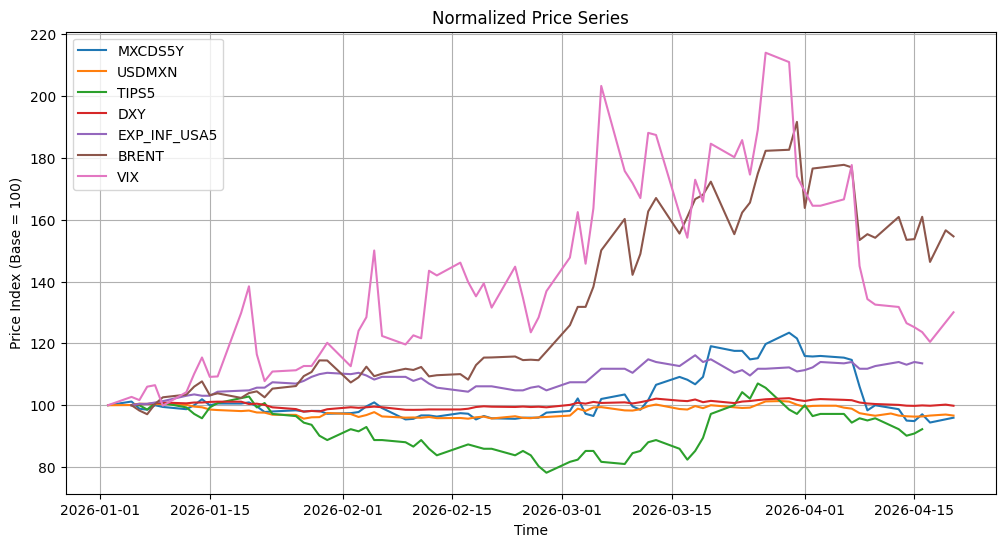

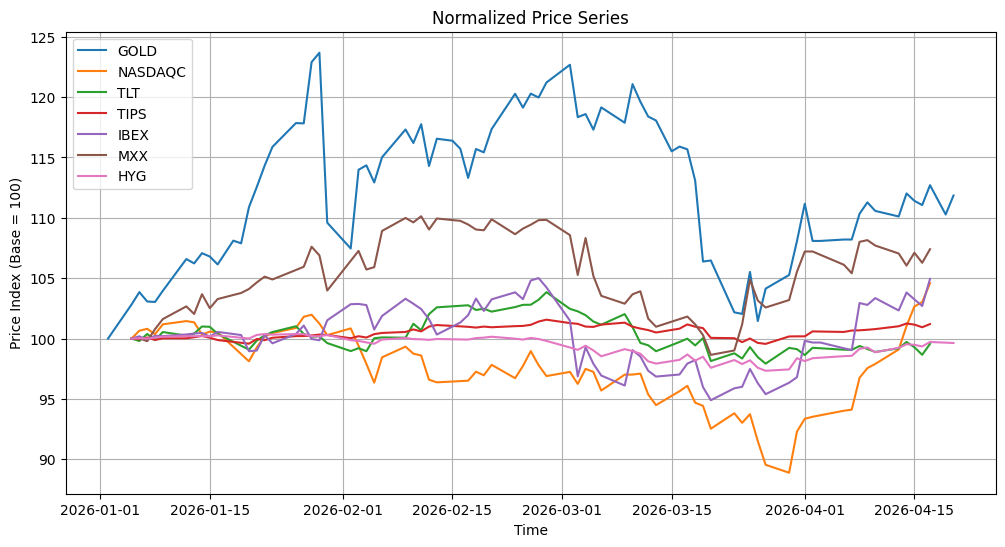

In [181]:
rics_up = ["MXCDS5Y", 'USDMXN', 'TIPS5', 'DXY', 'EXP_INF_USA5', 'BRENT', 'VIX'] # EXP_INF_USA10, EXP_INF_MX3, TIPS10
# EXP_INF_USA5 VS TIPS5, ¿Cúal explica a DXY? - Esto va cambiando como bien mencionamos.

rrm.plot_normalized_timeseries(
    rics_up,
    from_date="2026-01-01",
    base_value=100
)
rics_down = ['GOLD', 'NASDAQC', 'TLT', 'TIPS', 'IBEX', 'MXX', 'HYG'] # EXP_INF_USA5
rrm.plot_normalized_timeseries(
    rics_down,
    from_date="2026-01-01",
    base_value=100
)

Pendiente: 
* Anális horizonte 10
* Hacer insights sugeridos por cloud 
* Debemos de lograr explicar que sucede posteriormente de las ventanas expuestas que tuvieron valor explicativo, ventanas mensuales priorizar
* GARCH model?



---
Esto nos lleva a la segunda fase del proyecto... implementar nuevas cosas, en este caso una función que muestre los securites pero ahora con toda la información obtenida de cada benchmark y no perder esa información que podría llevarnos a crear un modelo de regresión multiple... 
Por otro lado debemos agregar mas benchmarks posibles con base al análisis realizado, pues nos dió insights de posibles modelos a crear y que pudieran explicar nuestros securites de interes o índices.

# Analisis general de securities y benchmarks
En este caso no queremos perder información, si bien es útil ver el security y benchmarks más frecuentes como lo hemos estado realizando, al final no estamos descontando dentro de la historia o haciendo notoria la informacion residual de esto lo cual puede llevar a análisis incorrectos, interpretaciones falsas o no lograr hacer match con la situación actual.

In [ ]:
def analizar_todo_el_df(df, metric='r2'):
    """
    Analiza TODOS los benchmarks de cada security, calculando extremos, 
    scores y representatividad para cada uno.
    """
    # 1. Identificar el security principal para mantener la referencia
    top_security_name = df['security'].value_counts().idxmax()
    totales_por_sec = df['security'].value_counts().to_dict()
    
    # 2. Preparar métrica de ordenamiento
    df_temp = df.copy()
    if metric == 'correlation':
        df_temp['metric_abs'] = df_temp[metric].abs()
    else:
        df_temp['metric_abs'] = df_temp[metric]

    # 3. Agrupar por par security-benchmark (TODOS)
    agrupado = df_temp.groupby(['security', 'benchmark']).agg(
        repeticiones=('benchmark', 'count'),
        max_metrica=('metric_abs', 'max')
    ).reset_index()

    # 4. Ordenar para que el más frecuente de cada sec aparezca primero
    resumen_base = agrupado.sort_values(['security', 'repeticiones', 'max_metrica'], 
                                       ascending=[True, False, False])

    resumen_base['total_obs'] = resumen_base['security'].map(totales_por_sec)
    resumen_base['pct_presencia'] = (resumen_base['repeticiones'] / resumen_base['total_obs']) * 100

    # 5. Extraer estadísticas de min/max R2 para cada par
    def get_stats(row):
        mask = (df['security'] == row['security']) & (df['benchmark'] == row['benchmark'])
        sub_df = df[mask]
        idx_min = sub_df['r2'].idxmin()
        idx_max = sub_df['r2'].idxmax()
        
        return pd.Series({
            'min_r2': sub_df.loc[idx_min, 'r2'],
            'corr_min': sub_df.loc[idx_min, 'correlation'],
            'score_min': sub_df.loc[idx_min, 'score'],
            'from_date_min': sub_df.loc[idx_min, 'from'],
            'to_date_min': sub_df.loc[idx_min, 'to'],
            'max_r2': sub_df.loc[idx_max, 'r2'],
            'corr_max': sub_df.loc[idx_max, 'correlation'],
            'score_max': sub_df.loc[idx_max, 'score'],
            'from_date_max': sub_df.loc[idx_max, 'from'],
            'to_date_max': sub_df.loc[idx_max, 'to']
        })

    detalles = resumen_base.apply(get_stats, axis=1)
    
    cols_base = ['security', 'benchmark', 'repeticiones', 'total_obs', 'pct_presencia']
    resumen_final = pd.concat([resumen_base[cols_base], detalles], axis=1)
    
    # Separar Principal (todas sus filas) y Complemento (todas sus filas)
    df_principal = resumen_final[resumen_final['security'] == top_security_name].reset_index(drop=True)
    df_complemento = resumen_final[resumen_final['security'] != top_security_name].reset_index(drop=True)
    
    return df_principal, df_complemento


In [22]:
def imprimir_desglose_total(df_resultados, titulo="DESGLOSE COMPLETO"):
    if df_resultados.empty:
        print(f"No hay datos para: {titulo}")
        return

    print("\n" + "█"*85)
    print(f"{titulo:^85}")
    print("█"*85)

    # Agrupamos por security para imprimir en bloques
    securities = df_resultados['security'].unique()

    for sec in securities:
        df_sec = df_resultados[df_resultados['security'] == sec]
        total_obs = df_sec['total_obs'].iloc[0]
        
        print(f"\n💎 SECURITY: {sec} (Total obs: {total_obs})")
        print(f"   " + "═"*75)

        for _, row in df_sec.iterrows():
            print(f"   🔸 Benchmark: {row['benchmark']}")
            print(f"      Frecuencia: {row['repeticiones']} [{row['pct_presencia']:.2f}% del security]")
            
            # Bloque de datos técnicos
            print(f"      📉 Min R2: {row['min_r2']:.4f} [r: {row['corr_min']:.4f}] (Score: {row['score_min']:.4f})")
            print(f"         Periodo: {row['from_date_min']} a {row['to_date_min']}")
            
            print(f"      📈 Max R2: {row['max_r2']:.4f} [r: {row['corr_max']:.4f}] (Score: {row['score_max']:.4f})")
            print(f"         Periodo: {row['from_date_max']} a {row['to_date_max']}")
            print(f"      " + "·"*60)

    print("\n" + "█"*85)


In [23]:
def imprimir_resumen_frecuencias(df):
    counts = df['security'].value_counts()
    sec_most_frequent = counts.idxmax()
    frequency = counts.max()
    percentage = (frequency / len(df)) * 100

    print(f"\n--- RESUMEN GENERAL DE ACTIVOS ---")
    print(f"El activo más frecuente es: {sec_most_frequent} ({percentage:.2f}% de la base)")

    # Encontrar el benchmark líder absoluto para el reporte rápido
    top_benchmark = df[df['security'] == sec_most_frequent]['benchmark'].value_counts().idxmax()
    
    # Localizar el mejor registro por Score del security líder
    df_lider = df[(df['security'] == sec_most_frequent) & (df['benchmark'] == top_benchmark)]
    row_best = df_lider.loc[df_lider['score'].idxmax()]

    print(f"Mejor ajuste absoluto para el líder:")
    print(f" > Sec: {row_best['security']} | Bench: {row_best['benchmark']}")
    print(f" > Score: {row_best['score']:.4f} | R2: {row_best['r2']:.4f}")
    print(f" > Periodo: {row_best['from']} a {row_best['to']}\n")


In [ ]:
def analizar_temporalidad_todos_los_pares(df):
    """
    Analiza cada combinación de Security-Benchmark y retorna la fila con 
    la mejor relación entre calidad (R2) y persistencia (Duración).
    """
    # 1. Copia y preparación de fechas
    df_temp = df.copy()
    df_temp['from'] = pd.to_datetime(df_temp['from'])
    df_temp['to'] = pd.to_datetime(df_temp['to'])
    
    # 2. Calcular duración y Score Temporal
    df_temp['duracion_dias'] = (df_temp['to'] - df_temp['from']).dt.days
    df_temp['score_temporal'] = df_temp['r2'] * df_temp['duracion_dias']
    
    # 3. Agrupar por Security y Benchmark, y tomar el ID del score máximo de cada grupo
    # idxmax() nos da el índice del mejor registro para cada par único
    indices_mejores = df_temp.groupby(['security', 'benchmark'])['score_temporal'].idxmax()
    
    # 4. Filtrar el DataFrame original usando esos índices
    resultado = df_temp.loc[indices_mejores].copy()
    
    # 5. Limpieza y ordenamiento (Opcional: del más persistente al menos)
    resultado = resultado.sort_values(by=['security', 'score_temporal'], ascending=[True, False]).reset_index(drop=True)
    
    # Reorganizar columnas para que sea fácil de leer
    cols = ['security', 'benchmark', 'r2', 'duracion_dias', 'score_temporal', 'from', 'to']
    return resultado[cols]

# --- Función para imprimir este análisis de forma legible ---
def imprimir_mejores_periodos(df_res):
    print("\n" + "◈"*80)
    print(f"{'MEJORES VENTANAS TEMPORALES (R2 x DURACIÓN)':^80}")
    print("◈"*80)
    
    for sec in df_res['security'].unique():
        print(f"\n📊 SECURITY: {sec}")
        sub = df_res[df_res['security'] == sec]
        for _, row in sub.iterrows():
            print(f"   ▫ Bench: {row['benchmark']:<15} | R2: {row['r2']:.4f} | Días: {row['duracion_dias']:>3} | Periodo: {row['from'].date()} ➜ {row['to'].date()}")
    
    print("\n" + "◈"*80)


In [ ]:
# POSIBLEMENTE ES UNA FUNCIÓN QUE NO USARÍA DEL TODO pues SIMPLEMNTE ME MUESTRA COMO SE COMPORTÓ CADA SECURITY CON CADA BENCHMARK SOBRE EL PERIODO ESPECIFICADO EN LA FUNCIÓN, no hay dinamismo.

def analizar_maxima_persistencia(df):
    """
    Retorna la fila con el periodo de tiempo más largo para cada par 
    Security-Benchmark, sin importar qué tan alto sea el R2.
    """
    # 1. Preparación de datos
    df_temp = df.copy()
    df_temp['from'] = pd.to_datetime(df_temp['from'])
    df_temp['to'] = pd.to_datetime(df_temp['to'])
    
    # 2. Calcular duración en días
    df_temp['duracion_dias'] = (df_temp['to'] - df_temp['from']).dt.days
    
    # 3. Identificar el índice de la duración máxima por cada grupo
    indices_max_duracion = df_temp.groupby(['security', 'benchmark'])['duracion_dias'].idxmax()
    
    # 4. Filtrar y limpiar
    resultado = df_temp.loc[indices_max_duracion].copy()
    resultado = resultado.sort_values(by=['security', 'duracion_dias'], ascending=[True, False]).reset_index(drop=True)
    
    # Seleccionar columnas relevantes
    cols = ['security', 'benchmark', 'duracion_dias', 'r2', 'from', 'to']
    return resultado[cols]


Las siguientes ventanas son pruebas del codigo para el año 2028 y 2020.

In [161]:
# 1. Análisis
r2_2018_p, r2_2018_c = analizar_todo_el_df(r2_2018)

# 2. Resumen rápido
imprimir_resumen_frecuencias(r2_2018)

# 3. Desglose detallado de TODO
imprimir_desglose_total(r2_2018_p, titulo="DETALLE COMPLETO DEL SECURITY PRINCIPAL")
imprimir_desglose_total(r2_2018_c, titulo="DETALLE COMPLETO DEL COMPLEMENTO")



--- RESUMEN GENERAL DE ACTIVOS ---
El activo más frecuente es: EXP_INF_USA5 (87.50% de la base)
Mejor ajuste absoluto para el líder:
 > Sec: EXP_INF_USA5 | Bench: TIPS5
 > Score: 2.5184 | R2: 0.6102
 > Periodo: 2018-02-01 a 2018-05-01


█████████████████████████████████████████████████████████████████████████████████████
                       DETALLE COMPLETO DEL SECURITY PRINCIPAL                       
█████████████████████████████████████████████████████████████████████████████████████

💎 SECURITY: EXP_INF_USA5 (Total obs: 21)
   ═══════════════════════════════════════════════════════════════════════════
   🔸 Benchmark: TIPS5
      Frecuencia: 21 [100.00% del security]
      📉 Min R2: 0.1550 [r: -0.3937] (Score: 0.7768)
         Periodo: 2018-04-02 a 2018-11-01
      📈 Max R2: 0.6102 [r: -0.7812] (Score: 2.5184)
         Periodo: 2018-02-01 a 2018-05-01
      ····························································

█████████████████████████████████████████████████████████████

In [162]:
# 1. Análisis
r2_2020_p, r2_2020_c = analizar_todo_el_df(r2_2020)

# 2. Resumen rápido
imprimir_resumen_frecuencias(r2_2020)

# 3. Desglose detallado de TODO
imprimir_desglose_total(r2_2020_p, titulo="DETALLE COMPLETO DEL SECURITY PRINCIPAL")
imprimir_desglose_total(r2_2020_c, titulo="DETALLE COMPLETO DEL COMPLEMENTO")



--- RESUMEN GENERAL DE ACTIVOS ---
El activo más frecuente es: EXP_INF_USA5 (52.94% de la base)
Mejor ajuste absoluto para el líder:
 > Sec: EXP_INF_USA5 | Bench: TIPS5
 > Score: 3.2445 | R2: 0.6493
 > Periodo: 2020-04-01 a 2020-10-30


█████████████████████████████████████████████████████████████████████████████████████
                       DETALLE COMPLETO DEL SECURITY PRINCIPAL                       
█████████████████████████████████████████████████████████████████████████████████████

💎 SECURITY: EXP_INF_USA5 (Total obs: 45)
   ═══════════════════════════════════════════════════════════════════════════
   🔸 Benchmark: TIPS5
      Frecuencia: 45 [100.00% del security]
      📉 Min R2: 0.3783 [r: -0.6151] (Score: 1.5673)
         Periodo: 2020-01-02 a 2020-04-01
      📈 Max R2: 0.6559 [r: -0.8099] (Score: 2.7278)
         Periodo: 2020-04-01 a 2020-07-01
      ····························································

█████████████████████████████████████████████████████████████

Con ello hemos realizado la primera implementación para no perder información que podría ser valiosa

### Analizando la sitación actual - 2026

**Empezamos a pensar en la importancia de las noticias que logran afectar al mercado como guerras, acuerdos de paz, aranceles, penalizaciones, etc.** Así como de aquellos activos que afecta directa e indirectamente.

Para el caso de 2026, hemos visto que el dolar pudo explicarse en parte por la inflación... pero que hay de aquellos activos que empezaron a sonar más debido a las noticias de guerra/acuerdos de paz, tal es el caso del petroleo principalmente (el cual puede no ser sostenido y cambiar en cualquier momento), veamos si logramos capturar ello de inicio.

In [172]:
benchmarks_x = ['EXP_INF_USA5', 'BRENT']
securities_y = ['DXY', 'USDMXN']
r2_2026_new = buscar_mejor_r2(x = benchmarks_x, y = securities_y, freq='W-FRI', start_date='2026-01-01', end_date='2026-04-20', min_obs = 20, min_corr=0)

In [173]:
# 1. Análisis
r2_2026_p, r2_2026_c = analizar_todo_el_df(r2_2026_new)

# 2. Resumen rápido
imprimir_resumen_frecuencias(r2_2026_new)

# 3. Desglose detallado de TODO
imprimir_desglose_total(r2_2026_p, titulo="DETALLE COMPLETO DEL SECURITY PRINCIPAL")
imprimir_desglose_total(r2_2026_c, titulo="DETALLE COMPLETO DEL COMPLEMENTO")


--- RESUMEN GENERAL DE ACTIVOS ---
El activo más frecuente es: DXY (50.00% de la base)
Mejor ajuste absoluto para el líder:
 > Sec: DXY | Bench: EXP_INF_USA5
 > Score: 1.4559 | R2: 0.4063
 > Periodo: 2026-02-20 a 2026-04-10


█████████████████████████████████████████████████████████████████████████████████████
                       DETALLE COMPLETO DEL SECURITY PRINCIPAL                       
█████████████████████████████████████████████████████████████████████████████████████

💎 SECURITY: DXY (Total obs: 156)
   ═══════════════════════════════════════════════════════════════════════════
   🔸 Benchmark: EXP_INF_USA5
      Frecuencia: 78 [50.00% del security]
      📉 Min R2: 0.0014 [r: -0.0367] (Score: 0.0049)
         Periodo: 2026-01-09 a 2026-03-06
      📈 Max R2: 0.4209 [r: -0.6487] (Score: 1.4452)
         Periodo: 2026-02-27 a 2026-04-10
      ····························································
   🔸 Benchmark: BRENT
      Frecuencia: 78 [50.00% del security]
      📉 Mi

Aquí seguimos aplicando las nuevas funciones que constrimos.

Bajo el mismo planteamiento que nos hicimos (*revelar/mostrar la relación del dolar con el petroleo en la actualidad*), lo que sigue es realizar un análisis de R2 y ventanas prolongadas, como se comportaron y sus características, que nos ayudarán a encontrar posibles cambios estructurales, es decir, que PUDO HABER explicando de mejor manera al activo de interés y sobre que periodo.


In [ ]:
# 1. Generar el análisis de temporalidad para todos los pares
# Esta función devolverá un DataFrame con los mejores periodos de cada relación
df_temporalidad_2026 = analizar_temporalidad_todos_los_pares(r2_2026_new)

# 2. Imprimir los resultados de forma legible 
imprimir_mejores_periodos(df_temporalidad_2026)

# 3. (Opcional) Si queremos ver solo los top 5 con mayor score temporal de todo el año
print("\nTOP 5 RELACIONES MÁS SÓLIDAS DEL 2026:")
print(df_temporalidad_2026.nlargest(5, 'score_temporal'))



◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈
                  MEJORES VENTANAS TEMPORALES (R2 x DURACIÓN)                   
◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈

📊 SECURITY: DXY
   ▫ Bench: BRENT           | R2: 0.3549 | Días:  63 | Periodo: 2026-02-13 ➜ 2026-04-17
   ▫ Bench: EXP_INF_USA5    | R2: 0.3499 | Días:  62 | Periodo: 2026-02-13 ➜ 2026-04-16

📊 SECURITY: USDMXN
   ▫ Bench: BRENT           | R2: 0.2733 | Días:  56 | Periodo: 2026-02-13 ➜ 2026-04-10
   ▫ Bench: EXP_INF_USA5    | R2: 0.2262 | Días:  56 | Periodo: 2026-02-13 ➜ 2026-04-10

◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈

TOP 5 RELACIONES MÁS SÓLIDAS DEL 2026:
  security     benchmark        r2  duracion_dias  score_temporal       from  \
0      DXY         BRENT  0.354936             63       22.360968 2026-02-13   
1      DXY  EXP_INF_USA5  0.349876             62       21.692312 2026-02-13   
2   U

Queda pendiente su conclusión, este se hará más adelante una vez aplicadas todas las herramientas potenciales y posibles que se me ocurran.

### Un breve análisis para el dolar y los actuales canales potencialmente explicativos.

In [176]:
benchmarks_x = ['EXP_INF_USA5', 'TIPS5', 'BRENT', 'SPX', 'GOLD', 'HYG', 'VIX']
securities_y = ['DXY', 'USDMXN']
r2_2026_new = buscar_mejor_r2(x = benchmarks_x, y = securities_y, freq='W-FRI', start_date='2026-01-01', end_date='2026-04-20', min_obs = 20, min_corr=0)

In [179]:
# 1. Análisis
r2_2026_p, r2_2026_c = analizar_todo_el_df(r2_2026_new)

# 2. Resumen rápido
imprimir_resumen_frecuencias(r2_2026_new)

# 3. Desglose detallado de TODO
imprimir_desglose_total(r2_2026_p, titulo="DETALLE COMPLETO DEL SECURITY PRINCIPAL")
imprimir_desglose_total(r2_2026_c, titulo="DETALLE COMPLETO DEL COMPLEMENTO")


--- RESUMEN GENERAL DE ACTIVOS ---
El activo más frecuente es: USDMXN (50.00% de la base)
Mejor ajuste absoluto para el líder:
 > Sec: USDMXN | Bench: SPX
 > Score: 2.3581 | R2: 0.6232
 > Periodo: 2026-02-06 a 2026-04-10


█████████████████████████████████████████████████████████████████████████████████████
                       DETALLE COMPLETO DEL SECURITY PRINCIPAL                       
█████████████████████████████████████████████████████████████████████████████████████

💎 SECURITY: USDMXN (Total obs: 546)
   ═══════════════════════════════════════════════════════════════════════════
   🔸 Benchmark: SPX
      Frecuencia: 78 [14.29% del security]
      📉 Min R2: 0.0685 [r: -0.2617] (Score: 0.2052)
         Periodo: 2026-01-02 a 2026-01-30
      📈 Max R2: 0.7415 [r: -0.8611] (Score: 2.2215)
         Periodo: 2026-03-13 a 2026-04-10
      ····························································
   🔸 Benchmark: VIX
      Frecuencia: 78 [14.29% del security]
      📉 Min R2: 0.011

In [ ]:
# 1. Generar el análisis de temporalidad para todos los pares
# Esta función te devolverá un DataFrame con los mejores periodos de cada relación
df_temporalidad_2026 = analizar_temporalidad_todos_los_pares(r2_2026_new)

# 2. Imprimir los resultados de forma legible en la consola
imprimir_mejores_periodos(df_temporalidad_2026)

# 3. (Opcional) Si quieres ver solo los top 5 con mayor score temporal de todo el año
print("\nTOP 5 RELACIONES MÁS SÓLIDAS DEL 2026:")
print(df_temporalidad_2026.nlargest(5, 'score_temporal'))



◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈
                  MEJORES VENTANAS TEMPORALES (R2 x DURACIÓN)                   
◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈◈

📊 SECURITY: DXY
   ▫ Bench: HYG             | R2: 0.3186 | Días:  77 | Periodo: 2026-01-30 ➜ 2026-04-17
   ▫ Bench: BRENT           | R2: 0.3549 | Días:  63 | Periodo: 2026-02-13 ➜ 2026-04-17
   ▫ Bench: EXP_INF_USA5    | R2: 0.3499 | Días:  62 | Periodo: 2026-02-13 ➜ 2026-04-16
   ▫ Bench: SPX             | R2: 0.2857 | Días:  70 | Periodo: 2026-02-06 ➜ 2026-04-17
   ▫ Bench: GOLD            | R2: 0.2495 | Días:  70 | Periodo: 2026-01-02 ➜ 2026-03-13
   ▫ Bench: VIX             | R2: 0.4321 | Días:  35 | Periodo: 2026-03-13 ➜ 2026-04-17
   ▫ Bench: TIPS5           | R2: 0.1402 | Días:  49 | Periodo: 2026-01-23 ➜ 2026-03-13

📊 SECURITY: USDMXN
   ▫ Bench: SPX             | R2: 0.4379 | Días: 105 | Periodo: 2026-01-02 ➜ 2026-04-17
   ▫ Bench: VIX

Logra mostrar que TIPS en este momento no es el canal principal... muestra la historia de risk off por situación geopolitica el cual afecta directamente a las expectativas de inflacion y que en conjunto con el petroleo, vix y hyg podrían ser canales potenciales que explican al dolar EN LA ACTUALIDA, HOY EN DÍA. Se puede se pueden crear modelos mas robustos.

### Análisis del posible cambio estructural que tuvo BBVA - IBEX
Analicemos como el mercado se pudo haber visto afectado ante declaraciones de guerra y paz por parte de Trump.
En este caso el focus será poder lograr entender los canales que mueven/explican a BBVA y a su vez a IBEX, si hubo cambios o no durante este periodo de incertidumbre por guerras.

La situación que nos motivó fue la siguiente... ante la declaración de una lucha por establecer aranceles y una posible guerra que se mostró en las noticias oficialmente el 28 de febrero de 2026, nos preguntamos si así como el dolar... los activos, empresas que cotizan en bolsa, pueden mostrar cambios estructuales motivadas por este tipo de noticias, ante una inversión mal hecha, analizamos la fecha en la que se hizo publica la noticia.

Este será nuestro focus en los siguientes bloques, analizar fechas entre activos e indicadores, su comportamiento y nivel de explicación **de manera dinámica**.

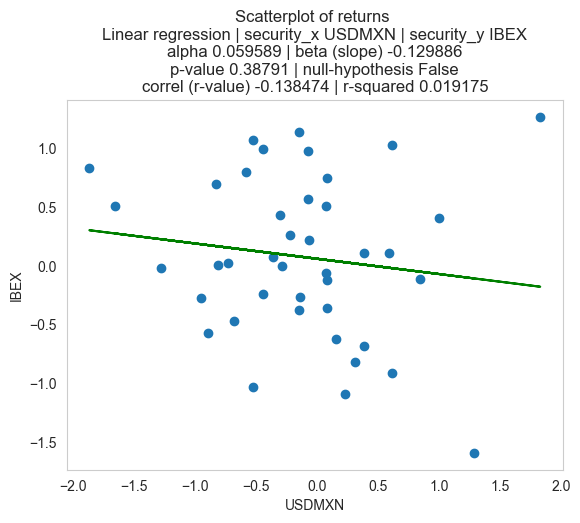

In [ ]:
model = rrm.model('USDMXN', 'IBEX', 6) # 'MXX', 'EXP_INF_MX10' 'TIPS5', 'TIPS10'
model.synchronise_timeseries( from_date='2026-01-01', to_date='2026-02-27') # Notamos una diferencia cuando analizamos el intervalo de 2020-02-28 a 2026-04-20... el dolar se vuelve más fuerte explicativamente para el IBEX!
model.compute_linear_reg()
model.plot_linear_reg()

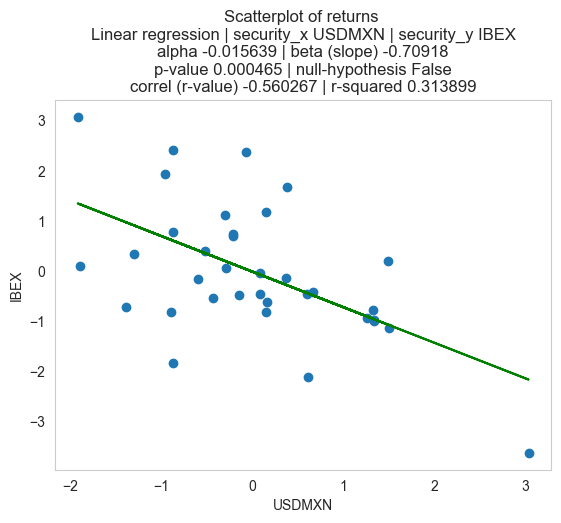

In [119]:
model = rrm.model('USDMXN', 'IBEX', 6) # 'MXX', 'EXP_INF_MX10' 'TIPS5', 'TIPS10'
model.synchronise_timeseries( from_date='2026-02-27')
model.compute_linear_reg()
model.plot_linear_reg()

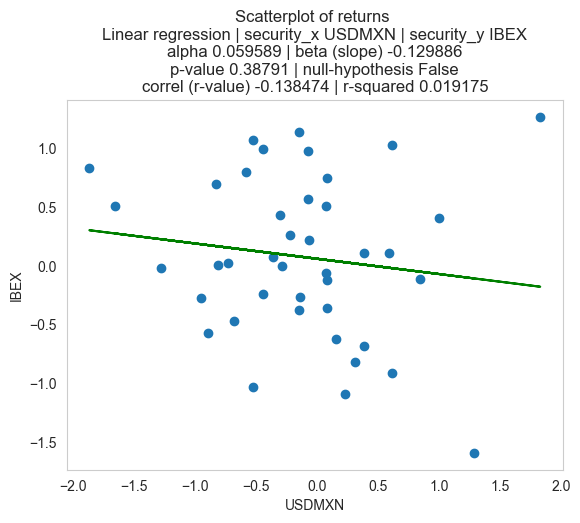

In [121]:
model = rrm.model('USDMXN', 'IBEX', 6) # 'MXX', 'EXP_INF_MX10' 'TIPS5', 'TIPS10'
model.synchronise_timeseries( from_date='2026-01-01', to_date='2026-02-28') 
model.compute_linear_reg() 
model.plot_linear_reg()

In [28]:
benchmarks_x = ['IBEX']
securities_y = ['DXY', 'USDMXN']
r2_2026_ = buscar_mejor_r2(x = benchmarks_x, y = securities_y, freq='W-FRI', start_date='2026-01-01', end_date='2026-04-19', min_obs = 20, min_corr=0)

In [29]:
r2_2026_

,security,benchmark,r2,correlation,beta,from,to,n_obs,score
0,USDMXN,IBEX,0.477794,-0.691227,-0.329194,2026-02-06,2026-03-06,21,1.454655
1,DXY,IBEX,0.397700,-0.630635,-0.150970,2026-02-06,2026-03-13,26,1.295745
2,USDMXN,IBEX,0.380780,-0.617074,-0.302182,2026-02-27,2026-04-10,30,1.295108
3,USDMXN,IBEX,0.345840,-0.588082,-0.291028,2026-02-20,2026-04-10,35,1.229582
4,DXY,IBEX,0.394275,-0.627913,-0.131064,2026-02-13,2026-03-13,21,1.200379
...,...,...,...,...,...,...,...,...,...
151,DXY,IBEX,0.000108,-0.010386,-0.004781,2026-01-09,2026-02-13,26,0.000352
152,DXY,IBEX,0.000097,0.009846,0.004505,2026-01-02,2026-02-13,31,0.000333
153,DXY,IBEX,0.000059,-0.007660,-0.003110,2026-01-23,2026-02-27,26,0.000192
154,DXY,IBEX,0.000062,0.007843,0.003381,2026-01-23,2026-02-20,21,0.000189


Con base a la busqueda de nuestro mejor r2... empezamos a analizar fechas específicas (de noticias) que pueden marcar un cambios de régimen.

In [ ]:
def consultar_fecha_especifica(df, fecha_buscada):
    """
    Busca todos los rangos que contienen la fecha especificada y
    los ordena por R2 de mayor a menor.
    """
    # 1. Asegurar formato datetime
    df_temp = df.copy()
    df_temp['from'] = pd.to_datetime(df_temp['from'])
    df_temp['to'] = pd.to_datetime(df_temp['to'])
    fecha_target = pd.to_datetime(fecha_buscada)
    
    # 2. Filtrar: la fecha debe estar entre 'from' y 'to'
    mascara = (fecha_target >= df_temp['from']) & (fecha_target <= df_temp['to'])
    resultado = df_temp[mascara].copy()
    
    if resultado.empty:
        print(f"No se encontraron rangos que cubran la fecha: {fecha_buscada}")
        return resultado

    # 3. Ordenar de mayor a menor R2
    resultado = resultado.sort_values(by='r2', ascending=False).reset_index(drop=True)
    
    # 4. Imprimir de forma estética
    print(f"\n🔍 Resultados para la fecha: {fecha_buscada}")
    print(f"{'Security':<15} | {'Benchmark':<15} | {'R2':<8} | {'Rango Detectado'}")
    print("-" * 75)
    for _, row in resultado.iterrows():
        print(f"{row['security']:<15} | {row['benchmark']:<15} | {row['r2']:.4f} | {row['from'].date()} a {row['to'].date()}")
        
    return resultado

# --- Ejemplo de uso ---
df_fecha = consultar_fecha_especifica(r2_2026_, '2026-02-28')



🔍 Resultados para la fecha: 2026-02-28
Security        | Benchmark       | R2       | Rango Detectado
---------------------------------------------------------------------------
USDMXN          | IBEX            | 0.4778 | 2026-02-06 a 2026-03-06
DXY             | IBEX            | 0.3977 | 2026-02-06 a 2026-03-13
DXY             | IBEX            | 0.3943 | 2026-02-13 a 2026-03-13
USDMXN          | IBEX            | 0.3808 | 2026-02-27 a 2026-04-10
DXY             | IBEX            | 0.3694 | 2026-02-06 a 2026-03-06
USDMXN          | IBEX            | 0.3508 | 2026-02-06 a 2026-03-13
USDMXN          | IBEX            | 0.3458 | 2026-02-20 a 2026-04-10
USDMXN          | IBEX            | 0.3324 | 2026-02-13 a 2026-03-13
USDMXN          | IBEX            | 0.3221 | 2026-02-27 a 2026-04-03
USDMXN          | IBEX            | 0.3139 | 2026-02-27 a 2026-04-17
USDMXN          | IBEX            | 0.3095 | 2026-02-06 a 2026-04-10
USDMXN          | IBEX            | 0.3038 | 2026-01-30 a 2026

In [ ]:
def buscar_cierres_cercanos(df, fecha_objetivo, margen_dias=3):
    """
    Busca los rangos cuya fecha 'to' esté cerca de la fecha objetivo
    dentro de un margen de días especificado.
    """
    # 1. Preparación de fechas
    df_temp = df.copy()
    df_temp['to'] = pd.to_datetime(df_temp['to'])
    df_temp['from'] = pd.to_datetime(df_temp['from'])
    target = pd.to_datetime(fecha_objetivo)
    
    # 2. Calcular la diferencia en días (valor absoluto)
    df_temp['diferencia_dias'] = (df_temp['to'] - target).dt.days.abs()
    
    # 3. Filtrar por el margen permitido
    resultado = df_temp[df_temp['diferencia_dias'] <= margen_dias].copy()
    
    if resultado.empty:
        print(f"No se encontraron rangos que terminaran cerca de {fecha_objetivo} (Margen: ±{margen_dias} días)")
        return resultado

    # 4. Ordenar por cercanía (los que terminaron EXACTO el día primero) y luego por R2
    resultado = resultado.sort_values(by=['diferencia_dias', 'r2'], ascending=[True, False]).reset_index(drop=True)
    
    # 5. Impresión elegante
    print(f"\n📅 Análisis de cierres cercanos a: {fecha_objetivo} (Margen: ±{margen_dias} días)")
    print(f"{'Security':<12} | {'Benchmark':<15} | {'Diferencia':<10} | {'To Date':<12} | {'R2'}")
    print("-" * 75)
    
    for _, row in resultado.iterrows():
        dias_str = f"{row['diferencia_dias']} días" if row['diferencia_dias'] != 0 else "¡Exacto!"
        print(f"{row['security']:<12} | {row['benchmark']:<15} | {dias_str:<10} | {row['to'].date()} | {row['r2']:.4f}")
        
    return resultado

# --- Ejemplo de uso ---
df_cierres = buscar_cierres_cercanos(r2_2026_, '2026-02-28', margen_dias=5)



📅 Análisis de cierres cercanos a: 2026-02-28 (Margen: ±5 días)
Security     | Benchmark       | Diferencia | To Date      | R2
---------------------------------------------------------------------------
USDMXN       | IBEX            | 1 días     | 2026-02-27 | 0.0245
USDMXN       | IBEX            | 1 días     | 2026-02-27 | 0.0239
USDMXN       | IBEX            | 1 días     | 2026-02-27 | 0.0192
USDMXN       | IBEX            | 1 días     | 2026-02-27 | 0.0182
USDMXN       | IBEX            | 1 días     | 2026-02-27 | 0.0175
DXY          | IBEX            | 1 días     | 2026-02-27 | 0.0023
DXY          | IBEX            | 1 días     | 2026-02-27 | 0.0016
DXY          | IBEX            | 1 días     | 2026-02-27 | 0.0014
DXY          | IBEX            | 1 días     | 2026-02-27 | 0.0011
DXY          | IBEX            | 1 días     | 2026-02-27 | 0.0001


In [ ]:
def buscar_inicios_posteriores(df, fecha_inicio_target, margen_dias=5):
    """
    Busca los rangos cuya fecha 'from' esté más cerca (o sea posterior) 
    a la fecha especificada, permitiendo un margen de desviación.
    """
    # 1. Preparación de fechas
    df_temp = df.copy()
    df_temp['from'] = pd.to_datetime(df_temp['from'])
    df_temp['to'] = pd.to_datetime(df_temp['to'])
    target = pd.to_datetime(fecha_inicio_target)
    
    # 2. Calcular la diferencia en días respecto al inicio (from)
    # Usamos el valor absoluto para detectar los que empezaron "un poquito antes" o "un poquito después"
    df_temp['desviacion_inicio'] = (df_temp['from'] - target).dt.days.abs()
    
    # 3. Filtrar por el margen de días
    resultado = df_temp[df_temp['desviacion_inicio'] <= margen_dias].copy()
    
    if resultado.empty:
        print(f"No se encontraron rangos que iniciaran cerca de {fecha_inicio_target} (Margen: ±{margen_dias} días)")
        return resultado

    # 4. Ordenar por menor desviación y luego por mejor R2
    resultado = resultado.sort_values(by=['desviacion_inicio', 'r2'], ascending=[True, False]).reset_index(drop=True)
    
    # 5. Impresión
    print(f"\n🚀 Análisis de inicios cercanos a: {fecha_inicio_target} (Margen: ±{margen_dias} días)")
    print(f"{'Security':<12} | {'Benchmark':<15} | {'Desviación':<12} | {'From Date':<12} | {'R2'}")
    print("-" * 80)
    
    for _, row in resultado.iterrows():
        desv_str = f"{row['desviacion_inicio']} días" if row['desviacion_inicio'] != 0 else "¡Exacto!"
        print(f"{row['security']:<12} | {row['benchmark']:<15} | {desv_str:<12} | {row['from'].date()} | {row['r2']:.4f}")
        
    return resultado

# --- Ejemplo de uso ---
df_inicios = buscar_inicios_posteriores(r2_2026_, '2026-02-28', margen_dias=3)



🚀 Análisis de inicios cercanos a: 2026-02-28 (Margen: ±3 días)
Security     | Benchmark       | Desviación   | From Date    | R2
--------------------------------------------------------------------------------
USDMXN       | IBEX            | 1 días       | 2026-02-27 | 0.3808
USDMXN       | IBEX            | 1 días       | 2026-02-27 | 0.3221
USDMXN       | IBEX            | 1 días       | 2026-02-27 | 0.3139
USDMXN       | IBEX            | 1 días       | 2026-02-27 | 0.2845
DXY          | IBEX            | 1 días       | 2026-02-27 | 0.2481
DXY          | IBEX            | 1 días       | 2026-02-27 | 0.2352
DXY          | IBEX            | 1 días       | 2026-02-27 | 0.1878
DXY          | IBEX            | 1 días       | 2026-02-27 | 0.1790


Ahora, como detectar estos cambios para oportunidades de inversión... y entender el mercado, cual es el canal principal que explicará un activo!
Notemos que el cambio fue... brutal repentinamente, como fue el caso para IBEX y el DOLAR, tras la incertidumbre y entonces risk off... IBEX es empezado a contar por una historia distinta, nosotros habiamos confundido las métricas cuando realizamos nuestra inersión y por eso se fue a pérdida, este código demuestra el cambio de régimen/canal que explica un activo, no es estable, va variando.

El cambio fue bajo el mismo día de incertidumbre que se llevó, 2026 un año que inicio normal, posteriomrente a finales de febrero vino la noticia de una posible guerra lo cual cambió el régimen directamente...
Basado en la información disponible, el inicio de las acciones bélicas y la comunicación oficial de que Estados Unidos entraba en guerra comenzó el 28 de febrero de 2026. 

El anuncio formal: Fue el 28 de febrero de 2026, cuando se dio a conocer el inicio de "operaciones militares mayores" y ataques aéreos contra Irán por parte de Estados Unidos e Israel.

In [ ]:
def detectar_cambio_regimen_beta(list_x, list_y, fecha_evento, ventana_dias=10, min_obs=5):
    """
    Identifica cambios bruscos en la relación estadística antes y después de un evento.
    """
    fecha_evento = pd.to_datetime(fecha_evento)
    
    # Definir ventanas
    pre_start = fecha_evento - pd.Timedelta(days=ventana_dias)
    pre_end   = fecha_evento - pd.Timedelta(days=1)
    
    post_start = fecha_evento
    post_end   = fecha_evento + pd.Timedelta(days=ventana_dias)
    
    resultados = []

    for sec in list_y:
        for bench in list_x:
            if sec == bench: continue
            
            # --- REGIMEN PRE-EVENTO ---
            m_pre = rrm.model(bench, sec, 6, model_type='macro')
            m_pre.synchronise_timeseries(pre_start.strftime('%Y-%m-%d'), pre_end.strftime('%Y-%m-%d'))
            
            # --- REGIMEN POST-EVENTO ---
            m_post = rrm.model(bench, sec, 6, model_type='macro')
            m_post.synchronise_timeseries(post_start.strftime('%Y-%m-%d'), post_end.strftime('%Y-%m-%d'))
            
            # Validar que tengamos suficientes datos en ambos lados
            if len(m_pre.timeseries) < min_obs or len(m_post.timeseries) < min_obs:
                continue
            
            m_pre.compute_linear_reg()
            m_post.compute_linear_reg()
            
            r2_pre = m_pre.r_squared
            r2_post = m_post.r_squared
            delta_r2 = r2_post - r2_pre
            
            # Solo nos interesan cambios significativos (Reglas Macro)
            # Un salto de 0.0 a 0.8 es un cambio de régimen masivo.
            cambio_detectado = "SÍ" if abs(delta_r2) > 0.3 else "NO"
            
            resultados.append({
                "security": sec,
                "benchmark": bench,
                "r2_antes": r2_pre,
                "r2_despues": r2_post,
                "cambio_r2": delta_r2,
                "corr_antes": m_pre.correlation,
                "corr_despues": m_post.correlation,
                "cambio_regimen": cambio_detectado,
                "obs_pre/post": f"{len(m_pre.timeseries)}/{len(m_post.timeseries)}"
            })

    df_cambios = pd.DataFrame(resultados)
    
    if not df_cambios.empty:
        # Ordenar por el cambio más drástico (valor absoluto del delta)
        df_cambios['abs_delta'] = df_cambios['cambio_r2'].abs()
        df_cambios = df_cambios.sort_values(by='abs_delta', ascending=False).drop(columns=['abs_delta'])
    
    return df_cambios.reset_index(drop=True)


benchmarks = ['USDMXN', 'DXY']
activos = ['BRENT']
fecha_noticia = '2026-04-01'
reporte_cambios = detectar_cambio_regimen_beta(benchmarks, activos, fecha_noticia, ventana_dias=7)
print(reporte_cambios)


  security benchmark  r2_antes  r2_despues  cambio_r2  corr_antes  \
0    BRENT    USDMXN  0.065389    0.677964   0.612575    0.255712   
1    BRENT       DXY  0.160720    0.750446   0.589726   -0.400899   

   corr_despues cambio_regimen obs_pre/post  
0      0.823386             SÍ          5/5  
1      0.866283             SÍ          5/5  


In [124]:
def detectar_cambio_regimen_robusto_beta(list_x, list_y, fecha_evento, ventana_dias=10, min_obs=3):
    """
    Detecta cambios de régimen ajustándose a la disponibilidad real de datos.
    """
    fecha_evento = pd.to_datetime(fecha_evento)
    resultados = []

    for sec in list_y:
        for bench in list_x:
            if sec == bench: continue
            
            m = rrm.model(bench, sec, 6, model_type='macro')
            
            # --- VENTANA PRE: Desde (evento - ventana) hasta (evento - 1) ---
            pre_start = (fecha_evento - pd.Timedelta(days=ventana_dias)).strftime('%Y-%m-%d')
            pre_end = (fecha_evento - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
            
            # --- VENTANA POST: Desde evento hasta el final de los datos disponibles ---
            post_start = fecha_evento.strftime('%Y-%m-%d')
            # Dejamos que el modelo tome lo que haya disponible después de la fecha
            post_end = (fecha_evento + pd.Timedelta(days=ventana_dias)).strftime('%Y-%m-%d')
            
            # Ejecutar sincronización para ambas ventanas
            m_pre = rrm.model(bench, sec, 6, model_type='macro')
            m_pre.synchronise_timeseries(pre_start, pre_end)
            
            m_post = rrm.model(bench, sec, 6, model_type='macro')
            m_post.synchronise_timeseries(post_start, post_end)

            # VALIDACIÓN: Si no hay datos suficientes, no saltamos, informamos cuántos hay
            n_pre = len(m_pre.timeseries) if m_pre.timeseries is not None else 0
            n_post = len(m_post.timeseries) if m_post.timeseries is not None else 0

            if n_pre < min_obs or n_post < min_obs:
                continue # O puedes agregar un print para saber qué par falló por falta de datos
            
            m_pre.compute_linear_reg()
            m_post.compute_linear_reg()
            
            delta_r2 = m_post.r_squared - m_pre.r_squared
            
            resultados.append({
                "security": sec,
                "benchmark": bench,
                "r2_antes": m_pre.r_squared,
                "r2_despues": m_post.r_squared,
                "cambio_r2": delta_r2,
                "score_post": m_post.r_squared * np.log(n_post),
                "obs_pre": n_pre,
                "obs_post": n_post,
                "periodo_post": f"{m_post.timeseries['Fecha'].min().date()} al {m_post.timeseries['Fecha'].max().date()}"
            })

    df_cambios = pd.DataFrame(resultados)
    if not df_cambios.empty:
        df_cambios = df_cambios.sort_values(by='cambio_r2', ascending=False).reset_index(drop=True)
    
    return df_cambios


In [125]:
benchmarks = ['USDMXN', 'DXY']
activos = ['BRENT']
fecha_noticia = '2026-04-08'
reporte_cambios = detectar_cambio_regimen_robusto_beta(benchmarks, activos, fecha_noticia, ventana_dias=7)
print(reporte_cambios)

  security benchmark  r2_antes  r2_despues  cambio_r2  score_post  obs_pre  \
0    BRENT       DXY  0.660079    0.599712  -0.060367     1.07454        4   
1    BRENT    USDMXN  0.599902    0.447404  -0.152498     0.80164        4   

   obs_post              periodo_post  
0         6  2026-04-08 al 2026-04-15  
1         6  2026-04-08 al 2026-04-15  


In [ ]:
# LA MISMA DE ARRIBA SOLO QUE CON ALTERTAS
def detectar_cambio_regimen_robusto(list_x, list_y, fecha_evento, ventana_dias=10, min_obs=3):
    """
    Detecta cambios de régimen con apoyo visual para identificar saltos de R2.
    """
    fecha_evento = pd.to_datetime(fecha_evento)
    resultados = []

    for sec in list_y:
        for bench in list_x:
            if sec == bench: continue
            
            # Definir rangos temporales
            pre_start = (fecha_evento - pd.Timedelta(days=ventana_dias)).strftime('%Y-%m-%d')
            pre_end = (fecha_evento - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
            post_start = fecha_evento.strftime('%Y-%m-%d')
            post_end = (fecha_evento + pd.Timedelta(days=ventana_dias)).strftime('%Y-%m-%d')
            
            # Modelos
            m_pre = rrm.model(bench, sec, 6, model_type='macro')
            m_pre.synchronise_timeseries(pre_start, pre_end)
            
            m_post = rrm.model(bench, sec, 6, model_type='macro')
            m_post.synchronise_timeseries(post_start, post_end)

            n_pre = len(m_pre.timeseries) if m_pre.timeseries is not None else 0
            n_post = len(m_post.timeseries) if m_post.timeseries is not None else 0

            if n_pre < min_obs or n_post < min_obs:
                continue
            
            m_pre.compute_linear_reg()
            m_post.compute_linear_reg()
            
            delta_r2 = m_post.r_squared - m_pre.r_squared
            
            # --- Lógica de Apoyo Visual ---
            if delta_r2 > 0.4:
                shift_label = "🚀 SALTO FUERTE"
            elif delta_r2 > 0.2:
                shift_label = "📈 AUMENTO"
            elif delta_r2 < -0.4:
                shift_label = "📉 COLAPSO"
            elif delta_r2 < -0.2:
                shift_label = "📉 DEBILITADO"
            else:
                shift_label = "➖ SIN CAMBIO"

            resultados.append({
                "security": sec,
                "benchmark": bench,
                "regime_shift": shift_label, # Columna visual
                "r2_antes": round(m_pre.r_squared, 4),
                "r2_despues": round(m_post.r_squared, 4),
                "delta_r2": round(delta_r2, 4),
                "obs_pre/post": f"{n_pre}/{n_post}",
                "fin_analisis": m_post.timeseries['Fecha'].max().date()
            })

    df_cambios = pd.DataFrame(resultados)
    if not df_cambios.empty:
        # Ordenar por el cambio más drástico (absoluto)
        df_cambios['abs_delta'] = df_cambios['delta_r2'].abs()
        df_cambios = df_cambios.sort_values(by='abs_delta', ascending=False).drop(columns=['abs_delta'])
    
    return df_cambios.reset_index(drop=True)


In [65]:
benchmarks = ['USDMXN', 'DXY']
activos = ['BRENT']
fecha_noticia = '2026-04-08'
reporte_cambios = detectar_cambio_regimen_robusto(benchmarks, activos, fecha_noticia, ventana_dias=7)
print(reporte_cambios)

  security benchmark  regime_shift  r2_antes  r2_despues  delta_r2  \
0    BRENT    USDMXN  ➖ SIN CAMBIO    0.5999      0.4474   -0.1525   
1    BRENT       DXY  ➖ SIN CAMBIO    0.6601      0.5997   -0.0604   

  obs_pre/post fin_analisis  
0          4/6   2026-04-15  
1          4/6   2026-04-15  


In [94]:
benchmarks = ['EXP_INF_USA5', 'TIPS5', 'BRENT']
activos = ['USDMXN', 'DXY']
fecha_noticia = '2026-02-28'
reporte_cambios = detectar_cambio_regimen_robusto(benchmarks, activos, fecha_noticia, ventana_dias=5)
print(reporte_cambios)

  security     benchmark  regime_shift  r2_antes  r2_despues  delta_r2  \
0      DXY         BRENT     📈 AUMENTO    0.6160      0.9345    0.3185   
1   USDMXN  EXP_INF_USA5  📉 DEBILITADO    0.2641      0.0005   -0.2636   
2   USDMXN         BRENT     📈 AUMENTO    0.1030      0.3062    0.2032   
3      DXY  EXP_INF_USA5  ➖ SIN CAMBIO    0.1552      0.3365    0.1813   
4   USDMXN         TIPS5  ➖ SIN CAMBIO    0.5742      0.4727   -0.1016   
5      DXY         TIPS5  ➖ SIN CAMBIO    0.1114      0.0616   -0.0498   

  obs_pre/post fin_analisis  
0          5/4   2026-03-05  
1          5/4   2026-03-05  
2          5/4   2026-03-05  
3          5/4   2026-03-05  
4          5/4   2026-03-05  
5          5/4   2026-03-05  


In [ ]:
benchmarks = ['USDMXN', 'DXY', 'IBEX']
activos = ['BBVA']
fecha_noticia = '2026-02-28'
reporte_cambios = detectar_cambio_regimen_robusto(benchmarks, activos, fecha_noticia, ventana_dias=5)
print(reporte_cambios)

  security benchmark    regime_shift  r2_antes  r2_despues  delta_r2  \
0     BBVA       DXY  🚀 SALTO FUERTE    0.0988      0.9435    0.8447   
1     BBVA    USDMXN  🚀 SALTO FUERTE    0.1213      0.7004    0.5791   
2     BBVA      IBEX    ➖ SIN CAMBIO    0.9685      0.9681   -0.0004   

  obs_pre/post fin_analisis  
0          5/4   2026-03-05  
1          5/4   2026-03-05  
2          5/4   2026-03-05  


# DE AQUÍ PARA ABAJO ESTÁ MAL, es de dudoso valor para aportar y cumpla supuestos generales.
Vale preguntarte: si quitas los 2-3 días de mayor movimiento extremo de ese período, ¿el R² se sostiene o colapsa?

In [33]:
'''# HABRÍA QUE CUIDAR LOS DÍAS QUE ENTRARON AL ANÁLISIS, PUES DÍAS POST Y PRE DE 2 DÍAS SOLO AÑADEN RUIDO A LA TABLA Y SU INTERPRETACIÓN ASI QUE HAY QUE TENER CUIDADO, UN RANGO ACEPTABLE PODRIA SER PARA EL NUMERO DE PRE DIAS IGUAL A 4, Y POST IGUAL A EXCEPCIÓN DE LOS ULTIMOS VALORES DE LA TABLA EN DONDE SE ACABA LA INFORMACIÓN.
def scan_regime_shift(list_x, list_y, start_date, end_date, ventana=5, plot=True):
    fechas_eval = pd.date_range(start=start_date, end=end_date, freq='B')
    max_data_date = pd.to_datetime(end_date)
    resultados = []

    for fecha in fechas_eval:
        for sec in list_y:
            for bench in list_x:
                if sec == bench: continue
                
                # Definir ventanas
                pre_start = (fecha - pd.Timedelta(days=ventana)).strftime('%Y-%m-%d')
                pre_end = (fecha - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
                post_limit = min(fecha + pd.Timedelta(days=ventana), max_data_date)
                post_start = fecha.strftime('%Y-%m-%d')
                post_end = post_limit.strftime('%Y-%m-%d')
                
                # --- PREVENCIÓN DE ERRORES ---
                try:
                    m_pre = rrm.model(bench, sec, 6)
                    m_pre.synchronise_timeseries(pre_start, pre_end)
                    
                    m_post = rrm.model(bench, sec, 6)
                    m_post.synchronise_timeseries(post_start, post_end)
                    
                    # Validar si el objeto m_pre/m_post tiene el atributo timeseries y no está vacío
                    has_pre = hasattr(m_pre, 'timeseries') and m_pre.timeseries is not None and not m_pre.timeseries.empty
                    has_post = hasattr(m_post, 'timeseries') and m_post.timeseries is not None and not m_post.timeseries.empty

                    # Obtener conteo de observaciones
                    n_pre = len(m_pre.timeseries) if has_pre else 0
                    n_post = len(m_post.timeseries) if has_post else 0

                    r2_pre = 0
                    if has_pre and n_pre >= 3:
                        m_pre.compute_linear_reg()
                        r2_pre = m_pre.r_squared
                    
                    r2_post = 0
                    if has_post and n_post >= 3:
                        m_post.compute_linear_reg()
                        r2_post = m_post.r_squared
                    
                    resultados.append({
                        'fecha': fecha,
                        'security': sec,
                        'benchmark': bench,
                        'r2_pre': r2_pre,
                        'r2_post': r2_post,
                        'delta': r2_post - r2_pre,
                        'n_obs_pre': n_pre,   # Nueva columna
                        'n_obs_post': n_post  # Nueva columna
                    })
                except Exception as e:
                    continue

    df_final = pd.DataFrame(resultados)

    if plot and not df_final.empty:
        plt.figure(figsize=(12, 6))
        sns.set_style("whitegrid")
        
        sns.lineplot(data=df_final, x='fecha', y='r2_pre', label='R2 Antes', color='gray', alpha=0.6)
        sns.lineplot(data=df_final, x='fecha', y='r2_post', label='R2 Después', color='blue')
        
        plt.title(f"Evolución de Regímenes: {list_y[0]} vs {list_x[0]}")
        plt.axvline(x=pd.to_datetime('2026-04-16'), color='red', linestyle='--', label='Corte de Datos')
        plt.ylabel("R-Squared")
        plt.legend()
        plt.show()

    return df_final

# Ejecución
# scan_regime_shift(['USDMXN'], ['BBVA'], '2026-02-20', '2026-04-22', ventana=5)
'''


'# HABRÍA QUE CUIDAR LOS DÍAS QUE ENTRARON AL ANÁLISIS, PUES DÍAS POST Y PRE DE 2 DÍAS SOLO AÑADEN RUIDO A LA TABLA Y SU INTERPRETACIÓN ASI QUE HAY QUE TENER CUIDADO, UN RANGO ACEPTABLE PODRIA SER PARA EL NUMERO DE PRE DIAS IGUAL A 4, Y POST IGUAL A EXCEPCIÓN DE LOS ULTIMOS VALORES DE LA TABLA EN DONDE SE ACABA LA INFORMACIÓN.\ndef scan_regime_shift(list_x, list_y, start_date, end_date, ventana=5, plot=True):\n    fechas_eval = pd.date_range(start=start_date, end=end_date, freq=\'B\')\n    max_data_date = pd.to_datetime(end_date)\n    resultados = []\n\n    for fecha in fechas_eval:\n        for sec in list_y:\n            for bench in list_x:\n                if sec == bench: continue\n                \n                # Definir ventanas\n                pre_start = (fecha - pd.Timedelta(days=ventana)).strftime(\'%Y-%m-%d\')\n                pre_end = (fecha - pd.Timedelta(days=1)).strftime(\'%Y-%m-%d\')\n                post_limit = min(fecha + pd.Timedelta(days=ventana), max_data_da

In [122]:
'''
def scan_regime_shift_asimetrico(list_x, list_y, start_date, end_date, ventana=5, plot=True):
    # Generar rango de fechas hasta el final de tus datos (04-22)
    fechas_eval = pd.date_range(start=start_date, end=end_date, freq='B')
    # Fecha límite real de tus datos (04-17 según mencionas)
    max_data_date = pd.to_datetime('2026-04-17') 
    
    resultados = []

    for fecha in fechas_eval:
        for sec in list_y:
            for bench in list_x:
                if sec == bench: continue
                
                # --- VENTANA PRE: Siempre busca hacia atrás ---
                pre_start = (fecha - pd.Timedelta(days=ventana)).strftime('%Y-%m-%d')
                pre_end = (fecha - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
                
                # --- VENTANA POST: Se ajusta al límite real ---
                post_start = fecha.strftime('%Y-%m-%d')
                limit_efectivo = max(fecha, max_data_date)
                post_end = limit_efectivo.strftime('%Y-%m-%d')
                
                try:
                    # Modelos
                    m_pre = rrm.model(bench, sec, 6)
                    m_pre.synchronise_timeseries(pre_start, pre_end)
                    
                    m_post = rrm.model(bench, sec, 6)
                    m_post.synchronise_timeseries(post_start, post_end)
                    
                    # Cálculo R2 Pre
                    r2_pre = 0
                    n_pre = len(m_pre.timeseries) if hasattr(m_pre, 'timeseries') and m_pre.timeseries is not None else 0
                    if n_pre >= 2:
                        m_pre.compute_linear_reg()
                        r2_pre = m_pre.r_squared
                    
                    # Cálculo R2 Post
                    r2_post = 0
                    n_post = len(m_post.timeseries) if hasattr(m_post, 'timeseries') and m_post.timeseries is not None else 0
                    if n_post >= 2:
                        m_post.compute_linear_reg()
                        r2_post = m_post.r_squared
                    
                    resultados.append({
                        'fecha': fecha,
                        'security': sec,
                        'benchmark': bench,
                        'r2_pre': r2_pre,
                        'r2_post': r2_post,
                        'delta': r2_post - r2_pre,
                        'dias_pre': n_pre,   # Nueva columna añadida
                        'dias_post': n_post
                    })
                except Exception:
                    continue

    df_final = pd.DataFrame(resultados)

    if plot and not df_final.empty:
        plt.figure(figsize=(14, 7))
        sns.set_style("darkgrid")
        
        sns.lineplot(data=df_final, x='fecha', y='r2_pre', label='R2 Pre (Explicación Pasada)', color='teal', linewidth=2)
        sns.lineplot(data=df_final, x='fecha', y='r2_post', label='R2 Post (Explicación Futura)', color='orange', linewidth=2)
        
        plt.axvspan(max_data_date, pd.to_datetime(end_date), color='gray', alpha=0.2, label='Zona sin Datos Post')
        plt.axvline(x=max_data_date, color='red', linestyle='--', label='Fin de Datos (04-17)')
        
        plt.title(f"Escaneo de Cambio de Régimen: {list_y} vs {list_x}\n(Ventana: {ventana} días)", fontsize=14)
        plt.ylabel("R-Squared")
        plt.xlabel("Fecha de Evaluación")
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    return df_final

# Ejecución
scan_regime_shift_asimetrico(['DXY'], ['TIPS5'], '2026-02-20', '2026-04-22', ventana=5)
'''

'\ndef scan_regime_shift_asimetrico(list_x, list_y, start_date, end_date, ventana=5, plot=True):\n    # Generar rango de fechas hasta el final de tus datos (04-22)\n    fechas_eval = pd.date_range(start=start_date, end=end_date, freq=\'B\')\n    # Fecha límite real de tus datos (04-17 según mencionas)\n    max_data_date = pd.to_datetime(\'2026-04-17\') \n    \n    resultados = []\n\n    for fecha in fechas_eval:\n        for sec in list_y:\n            for bench in list_x:\n                if sec == bench: continue\n                \n                # --- VENTANA PRE: Siempre busca hacia atrás ---\n                pre_start = (fecha - pd.Timedelta(days=ventana)).strftime(\'%Y-%m-%d\')\n                pre_end = (fecha - pd.Timedelta(days=1)).strftime(\'%Y-%m-%d\')\n                \n                # --- VENTANA POST: Se ajusta al límite real ---\n                post_start = fecha.strftime(\'%Y-%m-%d\')\n                limit_efectivo = max(fecha, max_data_date)\n                post_

## Contexto necesario para poder entender el mercado actual y poder explicar los resultados... 
Desde enero 2025: Trump amenaza con aranceles desde el día 1 de su mandato. El mercado lo toma como ruido político, no como señal estructural.
20 enero – 4 febrero 2025: Primeras implementaciones reales (China 10%, México/Canadá amenaza). El mercado empieza a cotizar riesgo pero con dudas sobre si se ejecutarían.

2 abril 2025 ("Día de la Liberación"): Aranceles recíprocos masivos anunciados. El Nasdaq llegó a caer más de 11% intradía y el S&P más de 8% en los días siguientes. pepperstone Este es el primer gran cambio de régimen en los mercados globales.

9 abril 2025: Trump anuncia pausa de 90 días. El S&P 500 añade ~$4.3 billones en valor de mercado ese día, su mejor jornada desde 2008. Diario Financiero Segundo cambio de régimen: risk-on masivo.

Agosto–diciembre 2025: Treguas parciales con China, negociaciones. Mercado en modo "esperar y ver".
Enero 2026: La Corte Suprema empieza a ser el tema central. El mercado ya anticipaba el fallo desde enero 2026, cuando se esperaba resolución tan pronto como ese mes.

**20 de febrero de 2026**: La Corte Suprema falla 6-3 declarando que la IEEPA no autoriza al presidente a imponer aranceles. 

El 26 de febrero Trump anuncia que buscará vías alternativas más agresivas. 

El 28 de febrero es EUA inicia un conflicto bélico activo contra Irán, con bombardeos aéreos y expandiéndose al Indo-Pacífico.

2 abril 2026: Se cumple un año. La Corte Suprema y el Tribunal Comercial Internacional habían declarado los aranceles ilegales, generando expectativas de reembolsos a importadores. 

8 abril 2026: El "acuerdo de paz" es en realidad la misma dinámica de pausa/tregua — cuando Trump señaló disposición a negociar con ciertos países y los mercados reaccionaron con rebote fuerte en bolsas europeas y emergentes.


--- ASSUMPTIONS TEST ---



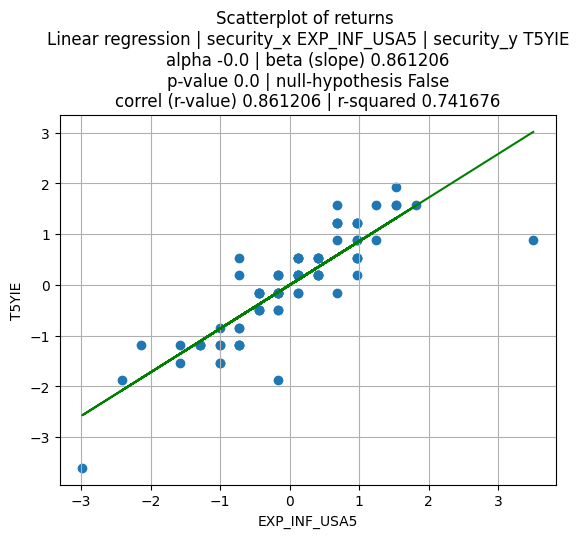

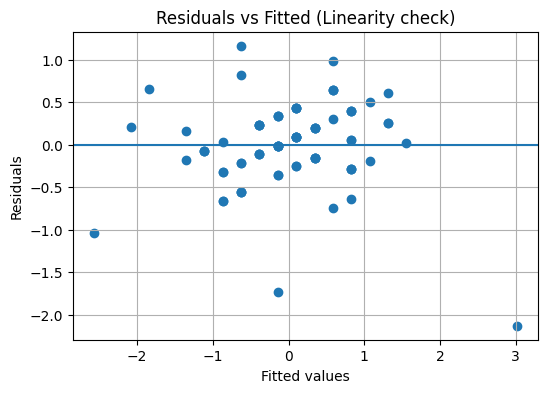

1) Linealidad:
- OK: nube aleatoria sin patrón
- MAL: forma curva, tendencia o estructura visible

2) Homocedasticidad (Breusch-Pagan):
p-value: 0.03289
→ Se RECHAZA H0: hay heterocedasticidad (varianza NO constante)

3) Normalidad (Shapiro-Wilk):
p-value: 0.00006
→ Se RECHAZA H0: residuos NO normales

4) Independencia (Durbin-Watson):
DW statistic: 2.56906
→ Posible autocorrelación negativa



In [96]:
model = rrm.model('EXP_INF_USA5', 'T5YIE', 6) # 'MXX', 'EXP_INF_MX10' 'TIPS5', 'TIPS10'
model.synchronise_timeseries(from_date='2026-01-01') # 2026-03-10
model.compute_linear_reg() # for capm class target_column='closing'
model.plot_linear_reg()
model.assumptions_test()

## Análisis del precio de TIPS vs el yield a 5 años
En ciertos entornos COMO EL ACTUAL... el precio del ETF y el yield pueden subir juntos por el ajuste de inflación. A pesar de ser un bono y no ser el movimiento natural esperado.

Si en nuestra muestra de entrenamiento la relación dominante es inversa pero ahora es directa, el modelo siempre va a equivocarse en dirección. Esa relación inversa entre precio y yield es natural en bonos.

In [211]:
import importlib
import macro_analysis.macro_tools as rrm
importlib.reload(rrm)

import Quant_Finance_Project.capm as capm
importlib.reload(capm)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 

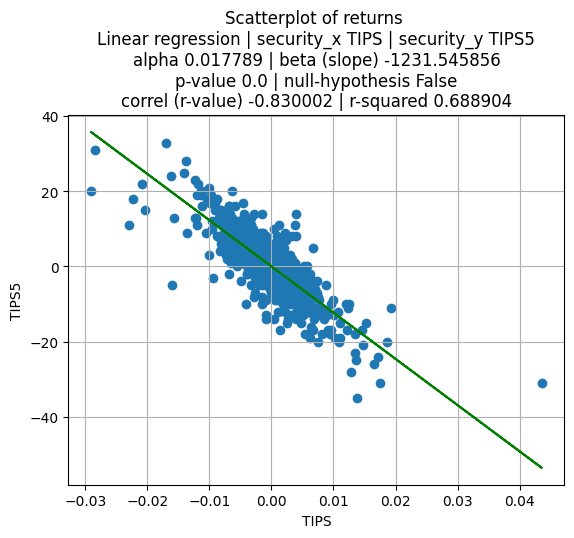

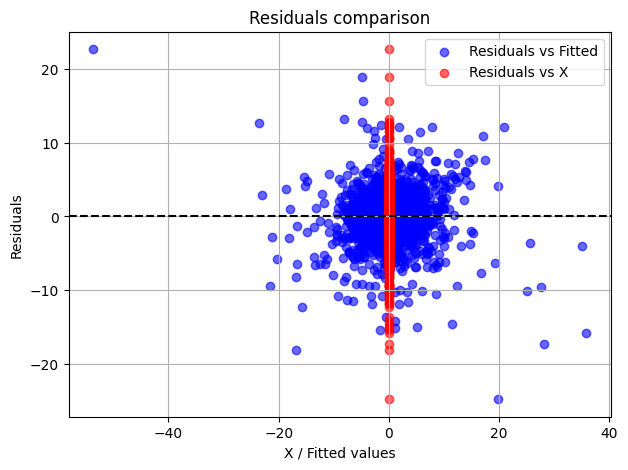

LINEALIDAD:
- OK: nube aleatoria sin patrón -> varianza no constante
- MAL: forma curva, tendencia o estructura visible

HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.44772
→ NO se rechaza H0: varianza constante

Para evaluar homocedasticidad correctamente, se usan residuos estandarizados o studentizados (más robusto)


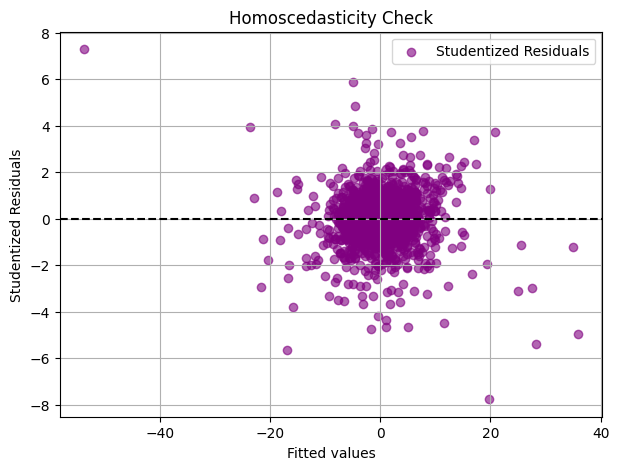

NORMALIDAD (Shapiro-Wilk):
p-value: 0.00000
→ Se RECHAZA H0: residuos NO normales

 INDEPENDENCIA (Durbin-Watson):
DW statistic: 2.18399
→ Sin evidencia de autocorrelación



In [213]:
model = rrm.model('TIPS', 'TIPS5', 6, model_type='macro') # 'MXX', 'EXP_INF_MX10' 'TIPS5', 'TIPS10'

model.synchronise_timeseries(log_returns=True) # from_date='2026-01-01'
# print(model.timeseries)
model.compute_linear_reg() 
model.plot_linear_reg()
model.linealidad()
model.homocedasticidad()
model.normalidad()
model.independencia()

Lambda Yeo-Johnson: 0.9978
→ No es necesaria transformación


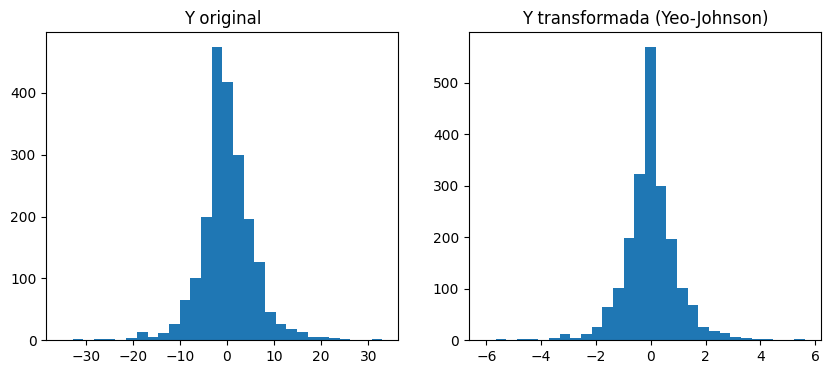

array([ 0.51026874, -0.52072919, -0.17626444, ...,  0.16740099,
        0.33889756, -0.52072919], shape=(2068,))

In [214]:
model.yeo_johnson_transform(True, True)

Lambda Yeo-Johnson: 0.9978
→ No es necesaria transformación
HOMOCEDASTICIDAD (Breusch-Pagan):
p-value: 0.94405
→ NO se rechaza H0: varianza constante

Para evaluar homocedasticidad correctamente, se usan residuos estandarizados o studentizados (más robusto)


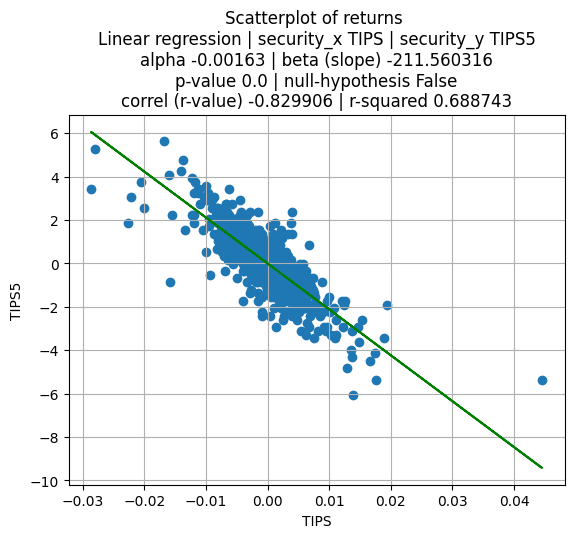

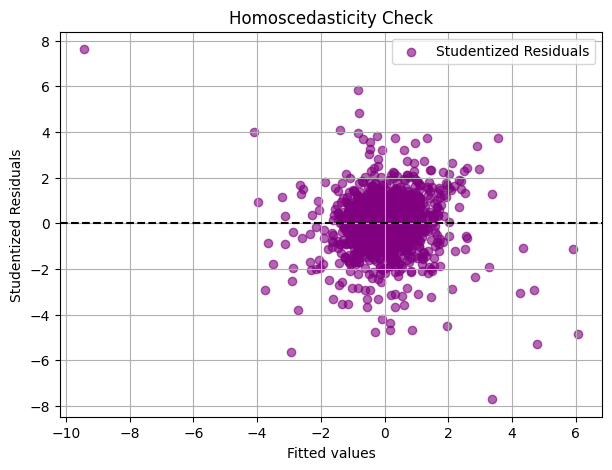

In [215]:
# Hago fit de nuevo con las nuevas variables que se me dieron

model.synchronise_timeseries()
model.y = model.timeseries[model.security_y].values

y_t = model.yeo_johnson_transform()
model.timeseries[model.security_y] = y_t

model.y = model.y_transformed
model.compute_linear_reg()
model.plot_linear_reg()
model.homocedasticidad()

In [221]:
# PARA HACER PREDICCIÓN TENGO QUE HACER LO SIGUEINTE UNA VEZ APLICADA LA TRANSFORMACIÓN
x = 111.57
y_pred_t = model.alpha + model.beta * x
y_pred_original = model.yj_model.inverse_transform(y_pred_t.reshape(-1,1))
print(y_pred_original)
model.pred_and_real_intervals_yeo(x)

# PARA MACRO
x_macro = 0.001615 # log(r_23/r_22)
model.pred_and_real_intervals_yeo(
    significance=0.01,
    x_value=x_macro,
    inverse=True
)

y = 6.422580344048764 / 100
print(1.30 + y)
# NO USAR ESTANDARIZACIÓN + YEO

[[-134206.08807286]]
Predicción: -134206.08807286274
Intervalo media: (np.float64(-138090.21426238053), np.float64(-130321.71987084349))
Intervalo real: (np.float64(-138090.21922709557), np.float64(-130321.71490550964))
Predicción: -1.970192790188662
Intervalo media: (np.float64(-2.169012141129976), np.float64(-1.7713447671235105))
Intervalo real: (np.float64(-10.313284572698079), np.float64(6.422580344048764))
1.3642258034404877


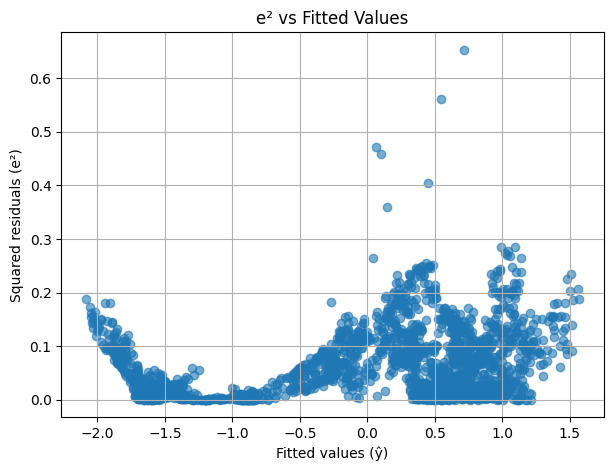


--- ESTIMATING VARIANCE FUNCTION g(x) ---

--- FITTING WLS ---

--- WLS MODEL IS NOW ACTIVE ---
Alpha: 13.660902065538082
Beta: -0.11946820511198486

--- WLS ASSUMPTIONS ---
2) Homocedasticidad (Breusch-Pagan):
p-value: 0.00000
→ Se RECHAZA H0: hay heterocedasticidad (varianza NO constante)

Para evaluar homocedasticidad correctamente, se usan residuos estandarizados o studentizados (más robusto)


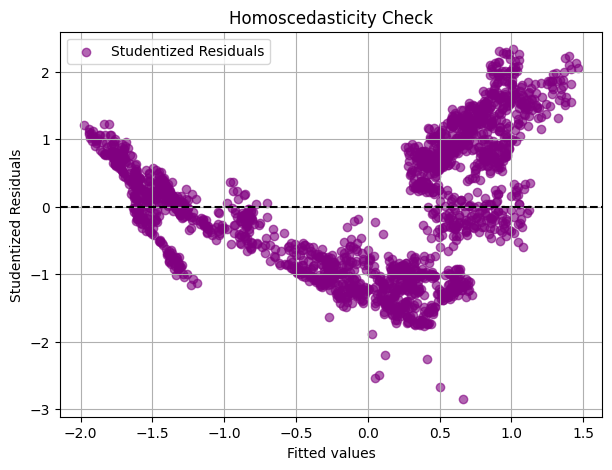

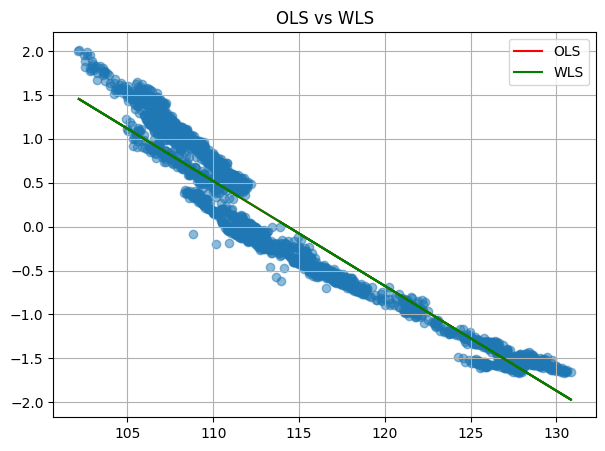

In [206]:
# 1. Plotea e^2 vs fitted para identificar el patron... lineal, no lineal ie nube, exponencial
model.plot_squared_residuals()
# Una vez identificado el patrón de arriba elige el método que creas necesario aux_reg o grouping que te dará 1/g y weights 
# Corro de nuevo la regresion con los parametros nuevos y observo que se cumplan las suposiciones...
model.run_wls_pipeline(use_fitted=True)

In [209]:

print('Sxx: ', model.sxx)
print('Sxy: ', model.sxy)
print('Syy: ', model.syy)

print('MCO - sum res^2:', model.MCO) # Puede ser o no igual a 0... que es lo que se busca idealmente pero basta con lograr que este se minimice.
print('Estimador varianza del modelo bajo MCO: ', model.mco_model_variance)
print('Varianza de b0: ', model.b0_variance)
print('Varianza de b1: ', model.b1_variance)

print('Desv std de x:', model.std_x)
print('Desv std de y:', model.std_y)
print('Media de x:', model.x_mean)
print('Media de y:', model.y_mean)

Sxx:  119390.9129111702
Sxy:  -19568.92190797872
Syy:  3294.8966953094778
MCO - sum res^2: 87.42725477099665
Estimador varianza del modelo bajo MCO:  0.04231716107018231
Varianza de b0:  0.004664502546135702
Varianza de b1:  3.5444205960354226e-07
Desv std de x: None
Desv std de y: None
Media de x: 114.4656914893617
Media de y: 0.5343762088974856


In [89]:
# x_statistics = (0.001616 - model.x_mean)/ model.std_x
# x_raw = 111.57
x_macro = 0.001615 # log(r_23/r_22)
model.pred_and_real_intervals(significance=0.01, x_value=x_macro) # Si el enfoque es macro y x es un precio de cierre entonces calcula el rendimiento/return al día que quieres predecir.
## Para statistics
# y = (1.0971756454224928 * model.std_y + model.y_mean)/100
# print(1.30 + y)

#### Para macro:
y = 2.1633170094014433 / 100 # Va el 'y' dado por el modelo que es la dif en bps
print(1.30 + y)

¿Cuál es la media esperada de Y (la media de Y es el valor ajustado) cuando x =  0.001615 ?:  -2.3600810755549997
Intervalo donde estará mi media esperada/predicción de y: (np.float64(-1.980719612728112), np.float64(-2.7394425383818874))
Intervalo para Y_x - ¿Dónde caerá un valor real Y_x dado x = 0.001615 ?: (np.float64(-8.33999945913795), np.float64(3.619837308027951)) con 99.0 % de confianza
1.3216331700940145


In [105]:
model.estimator_tests('b1') # estimator = 'b1', value_test = 0 --> es quivalente a realizar la prueba F, para este caso de regresión simple.

Predicted b1 by the model: -1422.822957
T test - t* de b1 : -30.350030228272267
Se rechaza H0 ( b1  =  0 ) tq b1 es diferente de  0 ya que 30.350030228272267 > 1.9674283869021496
Se rechaza H0 ( b1  >=  0 ) tq b1 < 0 ya que -30.350030228272267 < 1.649644319327056


In [107]:
model.anova_test()

Prueba F con valor:  921.124334302346
Hipótesis: H0 - todos los coeficientes (excepto intercepto) = 0 
 - p-value mas cercano a 0 mas ridículo H0 
 H1: al menos uno de los features (x_i) es diferente de 0
1.1102230246251565e-16


In [ ]:
# DADO QUE USAMOS EL ENFOQUE MACRO EN EL MODELOS ES DECIR RETURNS VS DIF EN BPS PARA TASAS MACRO...
import pandas as pd
import numpy as np

# ============================================================
# PARÁMETROS DEL MODELO
# ============================================================
ALPHA = model.alpha
BETA  = model.beta

# ============================================================
# DATOS DE ENTRADA
# ============================================================
precios_etf = {
    '2026-04-21': 111.22,
    '2026-04-22': 111.39,
    '2026-04-23': 111.57,
    '2026-04-24': 111.80,
}

yield_base_fecha = '2026-04-22'
yield_base_valor = 1.30  # en porcentaje, ej: 1.30 = 1.30%

# ============================================================
# FUNCIÓN
# ============================================================
def predecir_yield(precios_etf, yield_base_fecha, yield_base_valor, alpha, beta, log_returns=False):
    """
    Predice el yield de TIPS usando el modelo: delta_yield_bps = alpha + beta * return_decimal
    
    X: return del ETF en decimal        (ej: 0.001616)
    Y: diferencia de yield en bps       (ej: 8)
    Tasa almacenada en porcentaje        (ej: 1.30 significa 1.30%)
    
    Parámetros:
    -----------
    precios_etf      : dict {fecha_str: precio}
    yield_base_fecha : str  fecha del último yield oficial publicado
    yield_base_valor : float yield oficial en porcentaje (ej: 1.30)
    alpha            : float intercepto del modelo
    beta             : float pendiente del modelo
    log_returns      : bool usar log returns o returns simples
    """

    # --- construir dataframe ---
    df = pd.DataFrame(
        list(precios_etf.items()),
        columns=['fecha', 'precio_etf']
    )
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.sort_values('fecha').reset_index(drop=True)

    # --- calcular return en decimal ---
    df['precio_anterior'] = df['precio_etf'].shift(1)

    if not log_returns:
        df['return_decimal'] = df['precio_etf'] / df['precio_anterior'] - 1
    else:
        df['return_decimal'] = np.log(df['precio_etf'] / df['precio_anterior'])

    # --- aplicar modelo: resultado en bps enteros ---
    df['delta_yield_bps'] = alpha + beta * df['return_decimal']

    # --- convertir bps a porcentaje para reconstruir yield ---
    # bps enteros → porcentaje: dividir entre 100
    # ej: 8 bps → 0.08%
    df['delta_yield_pct'] = df['delta_yield_bps'] / 100

    # --- reconstruir yield acumulado desde yield base ---
    fecha_base = pd.to_datetime(yield_base_fecha)
    df['yield_estimado'] = np.nan

    idx_base = df[df['fecha'] == fecha_base].index
    if len(idx_base) > 0:
        df.loc[idx_base[0], 'yield_estimado'] = yield_base_valor

    for i in range(1, len(df)):
        if pd.isna(df.loc[i, 'yield_estimado']) and not pd.isna(df.loc[i-1, 'yield_estimado']):
            df.loc[i, 'yield_estimado'] = (
                df.loc[i-1, 'yield_estimado'] + df.loc[i, 'delta_yield_pct']
            )

    # --- resultado ---
    cols = ['fecha', 'precio_etf', 'return_decimal', 'delta_yield_bps', 'delta_yield_pct', 'yield_estimado']
    resultado = df[cols].copy()

    # formatear para lectura
    resultado['return_decimal']  = resultado['return_decimal'].round(6)
    resultado['delta_yield_bps'] = resultado['delta_yield_bps'].round(4)
    resultado['delta_yield_pct'] = resultado['delta_yield_pct'].round(6)
    resultado['yield_estimado']  = resultado['yield_estimado'].round(6)

    return resultado


# ============================================================
# EJECUTAR
# ============================================================
resultado = predecir_yield(
    precios_etf      = precios_etf,
    yield_base_fecha = yield_base_fecha,
    yield_base_valor = yield_base_valor,
    alpha            = ALPHA,
    beta             = BETA,
    log_returns      = False
)

print(resultado.to_string(index=False))

     fecha  precio_etf  return_decimal  delta_yield_bps  delta_yield_pct  yield_estimado
2026-04-21      111.22             NaN              NaN              NaN             NaN
2026-04-22      111.39        0.001529          -1.8548        -0.018548        1.300000
2026-04-23      111.57        0.001616          -1.9624        -0.019624        1.280376
2026-04-24      111.80        0.002061          -2.5110        -0.025110        1.255266


In [35]:
# CUANDO USAMOS EL ENFOQUE ESTADÍSTICO, ES DECIR RETURNS ESTANDARIZADOS VS DIF EN BPS ESTANDARIZADOS USAMOS...
import pandas as pd
import numpy as np

# ============================================================
# PARÁMETROS DEL MODELO ESTANDARIZADO
# ============================================================
ALPHA = model.alpha  # con estandarizados suele ser ~0
BETA  = model.beta   # con estandarizados era ~-1

# --- estadísticos del entrenamiento (guárdalos cuando calibras) ---
# X = return decimal
MEAN_X = model.x_mean  
STD_X  = model.std_x

# Y = dif en bps
MEAN_Y = model.y_mean   
STD_Y  = model.std_y     

# ============================================================
# DATOS DE ENTRADA
# ============================================================
precios_etf = {
    '2026-04-21': 111.22,
    '2026-04-22': 111.39,
    '2026-04-23': 111.57,
    '2026-04-24': 111.80,
}

yield_base_fecha = '2026-04-22'
yield_base_valor = 1.30

# ============================================================
# FUNCIÓN
# ============================================================
def predecir_yield_estandarizado(
    precios_etf, yield_base_fecha, yield_base_valor,
    alpha, beta,
    mean_x, std_x, mean_y, std_y,
    log_returns=False
):
    """
    Predice yield usando modelo calibrado con X e Y estandarizados.

    X original : return del ETF en decimal      (ej: 0.001616)
    Y original : dif de yield en bps enteros    (ej: 8)
    Tasa       : almacenada en porcentaje        (ej: 1.30%)

    Parámetros de estandarización deben venir del set de entrenamiento.
    """

    # --- construir dataframe ---
    df = pd.DataFrame(
        list(precios_etf.items()),
        columns=['fecha', 'precio_etf']
    )
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.sort_values('fecha').reset_index(drop=True)

    # --- Step 1: return en decimal (igual que tu código original) ---
    df['precio_anterior'] = df['precio_etf'].shift(1)

    if not log_returns:
        df['return_decimal'] = df['precio_etf'] / df['precio_anterior'] - 1
    else:
        df['return_decimal'] = np.log(df['precio_etf'] / df['precio_anterior'])

    # --- Step 2: estandarizar X con estadísticos del entrenamiento ---
    df['return_std'] = (df['return_decimal'] - mean_x) / std_x

    # --- Step 3: aplicar modelo → Y estandarizado ---
    df['delta_yield_std'] = alpha + beta * df['return_std']

    # --- Step 4: des-estandarizar → bps enteros ---
    df['delta_yield_bps'] = df['delta_yield_std'] * std_y + mean_y

    # --- Step 5: convertir bps a porcentaje para acumular ---
    df['delta_yield_pct'] = df['delta_yield_bps'] / 100

    # --- Step 6: reconstruir yield acumulado ---
    fecha_base = pd.to_datetime(yield_base_fecha)
    df['yield_estimado'] = np.nan

    idx_base = df[df['fecha'] == fecha_base].index
    if len(idx_base) > 0:
        df.loc[idx_base[0], 'yield_estimado'] = yield_base_valor

    for i in range(1, len(df)):
        if pd.isna(df.loc[i, 'yield_estimado']) and not pd.isna(df.loc[i-1, 'yield_estimado']):
            df.loc[i, 'yield_estimado'] = (
                df.loc[i-1, 'yield_estimado'] + df.loc[i, 'delta_yield_pct']
            )

    # --- resultado ---
    cols = ['fecha', 'precio_etf', 'return_decimal', 'return_std',
            'delta_yield_std', 'delta_yield_bps', 'delta_yield_pct', 'yield_estimado']
    resultado = df[cols].copy().round(6)

    return resultado


# ============================================================
# EJECUTAR
# ============================================================
resultado = predecir_yield_estandarizado(
    precios_etf      = precios_etf,
    yield_base_fecha = yield_base_fecha,
    yield_base_valor = yield_base_valor,
    alpha            = ALPHA,
    beta             = BETA,
    mean_x           = MEAN_X,
    std_x            = STD_X,
    mean_y           = MEAN_Y,
    std_y            = STD_Y,
    log_returns      = False
)

print(resultado.to_string(index=False))

     fecha  precio_etf  return_decimal  return_std  delta_yield_std  delta_yield_bps  delta_yield_pct  yield_estimado
2026-04-21      111.22             NaN         NaN              NaN              NaN              NaN             NaN
2026-04-22      111.39        0.001529    0.389553        -0.323308        -1.882017        -0.018820        1.300000
2026-04-23      111.57        0.001616    0.411838        -0.341804        -1.989682        -0.019897        1.280103
2026-04-24      111.80        0.002061    0.525389        -0.436045        -2.538270        -0.025383        1.254720


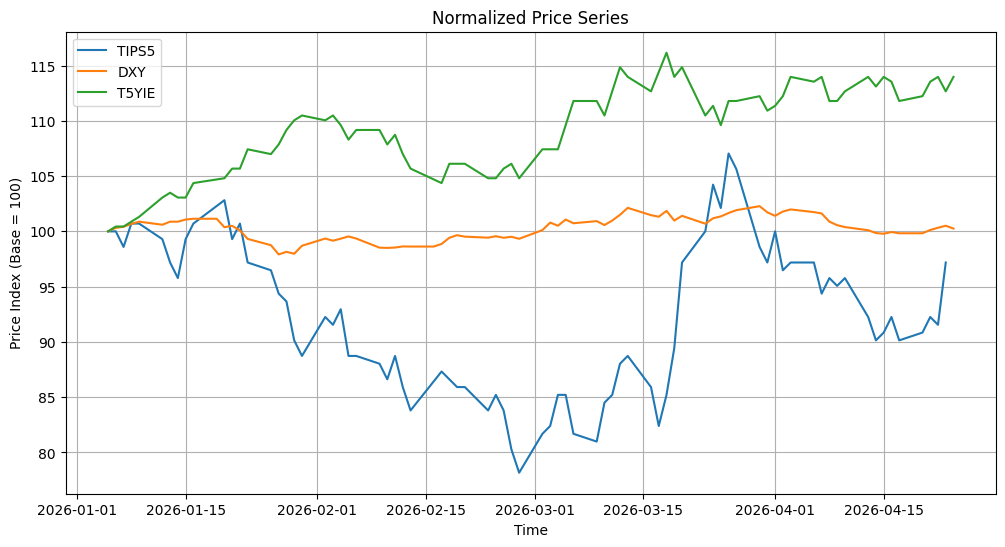

In [92]:
rrm.plot_normalized_timeseries(['TIPS5', 'DXY', 'T5YIE'], from_date='2026-01-01')

<bound method model.assumptions_test of <macro_analysis.macro_tools.model object at 0x128f52560>>

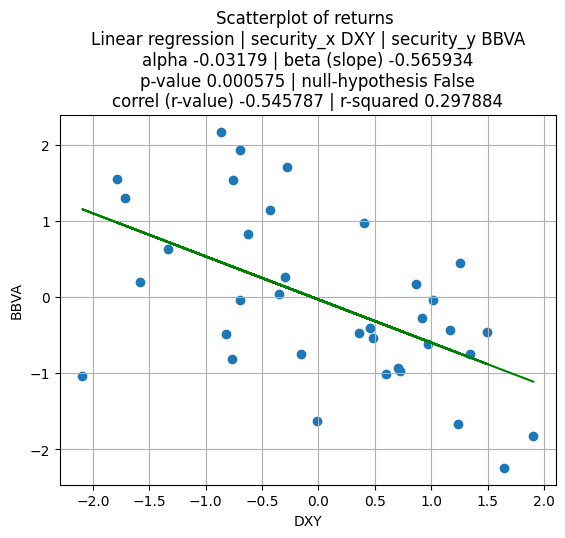

In [28]:
model = rrm.model('DXY', 'BBVA', 6) # '('DXY', 'EXP_INF_USA5'
model.synchronise_timeseries(from_date='2026-03-01') # from_date='2025-10-24', to_date='2026-01-02'
model.compute_linear_reg() # for capm class target_column='closing'
model.plot_linear_reg()
model.assumptions_test



--- ASSUMPTIONS TEST ---



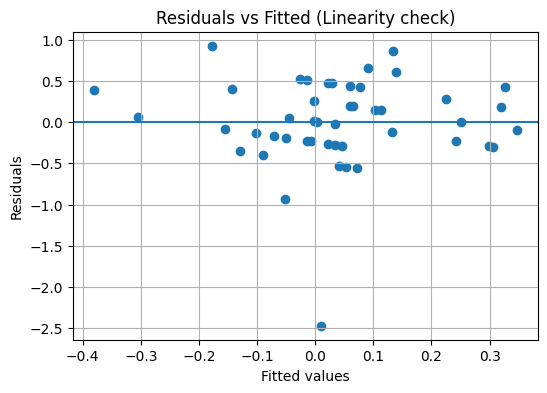

1) Linealidad:
- OK: nube aleatoria sin patrón
- MAL: forma curva, tendencia o estructura visible

2) Homocedasticidad (Breusch-Pagan):
p-value: 0.70008
→ NO se rechaza H0: varianza constante

3) Normalidad (Shapiro-Wilk):
p-value: 0.00003
→ Se RECHAZA H0: residuos NO normales

4) Independencia (Durbin-Watson):
DW statistic: 1.54482
→ Sin evidencia de autocorrelación



In [7]:
model = rrm.model('DXY', 'EXP_INF_USA5', 6) # 'MXX', 'EXP_INF_MX10' 'TIPS5', 'TIPS10'
model.synchronise_timeseries(from_date='2025-10-23', to_date='2026-01-01') # 2026-03-10
model.compute_linear_reg() # for capm class target_column='closing'
model.assumptions_test()

**DXY vs TIPS5: El Canal de Tasas Reales**

El patrón más relevante aquí:
20-26 feb (post fallo Corte Suprema): r2_pre altísimo (0.87 el 26-feb), r2_post cae (0.76). El canal de tasas reales explicaba bien al dólar antes del fallo pero empieza a perder fuerza después.

Para el día del ataque, es decir el 28 de febrero... no había cambio de régimen, las tasas reales seguían explicando en mayor parte al dolar, la inflación no entraba en juego aún a pesar de que el petroleo ya estaba. Recordemos que la alza del petroleo provocaba o daba como efecto al segundo canal que era la inflación esperada.

2-4 mar: r2_pre cerca de 0.79-0.83, r2_post colapsa a 0.04-0.008. La relación TIPS→DXY se rompe completamente. El dólar dejó de seguir las tasas reales. ¿Por qué? Porque el riesgo político (¿reimpondrá Trump aranceles?) dominó completamente sobre la señal de tasas reales. Escenario A activo: inflación/política domina, no tasas reales.

11-13 mar: r2_post salta a 0.80 y luego 0.70. La relación se reactiva brevemente. La interpretación: en ese período el mercado volvió momentáneamente a operar con lógica de fundamentos (tasas reales → dólar) antes de que el siguiente evento político la volviera a romper.
Recordemos que marzo fue un mes meh en noticias, podría explicar el hecho de que el dolar volviese a explicarse a travez de tasas reales.

13-14 abr: r2_post = 0.87 y 0.87. Los más altos del período completo para DXY-TIPS. En estos días la relación tasas reales → dólar fue muy fuerte mirando hacia adelante. Coincide con el período post-tregua del 8 de abril donde el mercado, al reducirse el riesgo político, volvió a operar sobre fundamentos macroeconómicos. En este periodo de post-tregua el petroleo habia bajado, asi que la inflación esperada tras esto... sería lo último en que preocuparse.



## Un pequeño análisis de inversion, que resultó mal 
Aquí tienes la redacción limpia de tu proceso de análisis:
Análisis Macroeconómico y Técnico: BBVA como Vehículo de Inversión
1. Contexto y Variable Explicativa Principal
En el entorno geopolítico actual, el tipo de cambio del dólar estadounidense (DXY) ha mostrado una relación estrecha con la inflación esperada o breakeven inflation. Con base en este diagnóstico, se identificó como variable proxy al ETF de TIPS, cuyo precio refleja de manera inversa el comportamiento de las tasas reales. Dado que el Departamento del Tesoro de Estados Unidos publica los yields oficiales de TIPS con un rezago de aproximadamente dos días, se optó por utilizar el precio del ETF como señal adelantada para anticipar el comportamiento de dichas tasas.
2. Construcción del Modelo: TIPS ETF → DXY
Se aplicó un modelo de regresión lineal simple entre los retornos del ETF de TIPS y los cambios en puntos base del yield oficial de TIPS publicado por el gobierno estadounidense. El uso de retornos frente a cambios en bps —equivalentes bajo estandarización— resuelve el problema de regresión espuria presente en series de tiempo financieras en niveles. El modelo fue sometido a pruebas formales de supuestos: linealidad, homocedasticidad, normalidad de residuales e independencia.
Con base en este modelo, se estimó que en los días subsecuentes al análisis el breakeven tendería al alza. Dado que el DXY ha mostrado una correlación significativa con esta variable en el período de estudio, se interpreta dicho movimiento como una señal de posible debilitamiento del dólar.
3. Análisis Técnico del DXY
Complementando el análisis cuantitativo, se realizó un estudio de soportes y resistencias sobre el gráfico del DXY. Se identificó un nivel de soporte relevante en la zona de 90, consistente con la expectativa de corrección derivada del modelo. El análisis técnico funciona en este marco como capa de confirmación, no como base de la tesis.
4. Cambio de Régimen en BBVA y Selección del Período de Calibración
Se identificó un cambio estructural en la relación entre el DXY y la acción de BBVA a partir del período correspondiente al ataque de Irán, evento a partir del cual BBVA comenzó a mostrar una sensibilidad significativamente mayor al movimiento del dólar. Con anterioridad a dicha fecha, el R² del modelo era bajo; a partir de ese quiebre, el coeficiente de determinación aumentó de forma notable.
Con base en este diagnóstico, el modelo de regresión lineal simple entre DXY y BBVA fue calibrado utilizando exclusivamente datos posteriores a ese evento, buscando capturar el régimen de correlación vigente. Se reconoce como limitación el tamaño reducido de muestra resultante, y se complementa con evidencia empírica directa: durante los episodios de alza del dólar generados por declaraciones de Trump, BBVA mostró caídas relevantes, y fue solo ante el anuncio de un acuerdo de paz —que permitió al mercado respirar— cuando la acción recuperó terreno. Esta observación valida la dirección causal asumida en el modelo.
5. Proyección sobre BBVA y Análisis Técnico
Aplicando el modelo DXY → BBVA, y bajo el escenario de debilitamiento del dólar señalado por el breakeven, se estima que BBVA podría alcanzar nuevamente niveles cercanos a sus máximos históricos recientes. Esta proyección es consistente con el análisis técnico de la acción: BBVA ha operado históricamente dentro de canales definidos por líneas de soporte y resistencia, y en el momento del análisis se encuentra en la parte baja del canal, con dos velas rojas de cuerpo amplio seguidas de una vela verde de cuerpo débil, lo que sugiere una posible continuación bajista hasta el soporte o bien un punto de inflexión al alza congruente con la señal macro.
6. Variable Pendiente: USDMXN
Se reconoce como paso siguiente la incorporación del tipo de cambio USD/MXN al análisis, dado que México representa el principal mercado de BBVA por volumen de utilidades. Esta variable podría matizar o reforzar la tesis, y su análisis se contempla como extensión natural del modelo actual.
7. Riesgo Principal Identificado
El riesgo más relevante identificado es de naturaleza no modelable: declaraciones o decisiones inesperadas por parte de la administración Trump pueden generar movimientos abruptos en el DXY que rompan los niveles técnicos identificados y alteren el comportamiento esperado de BBVA independientemente de los fundamentos macro.

Aquí está la tensión real que veo:
Tu modelo dice que el breakeven va a subir, lo que presionaría al DXY a la baja, lo que beneficiaría a BBVA. Pero el mecanismo de transmisión que observaste empíricamente funciona vía noticias geopolíticas de alto impacto, no solo vía movimiento gradual del DXY. Eso significa que la velocidad y el catalizador importan tanto como la dirección.
Si el DXY cae gradualmente por fundamentos macro, BBVA podría moverse poco o con ruido. Si cae porque Trump dice algo conciliador o hay un acuerdo geopolítico, BBVA reacciona fuerte y rápido. Son dos escenarios con el mismo desenlace en tu modelo pero con timing y magnitud muy distintos.